# CNNs avec Keras sur des données de paysage

## Vérification de l'utilisation de GPU

Allez dans le menu `Exécution > Modifier le type d'execution` et vérifiez que l'on est bien en Python 3 et que l'accélérateur matériel est configuré sur « GPU ».

In [1]:
!nvidia-smi

Wed Oct  7 13:50:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:04:00.0 Off |                    0 |
| N/A   45C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Téléchargement du dataset Landscape depuis un repo git

In [2]:
!wget -qO- https://github.com/shuuchuu/datasets/raw/refs/heads/main/ghsparse.sh | bash -s landscape
!ls landscape
print("***")
!ls -l landscape/seg_train
print("***")
!ls -l landscape/seg_pred

remote: Enumerating objects: 2, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 2 (delta 0), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (2/2), 1.94 KiB | 1.94 MiB/s, done.
remote: Enumerating objects: 24289, done.
remote: Counting objects: 100% (24289/24289), done.
remote: Compressing objects: 100% (24289/24289), done.
remote: Total 24289 (delta 0), reused 24289 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24289/24289), 341.65 MiB | 4.60 MiB/s, done.
Updating files: 100% (24336/24336), done.
✓ landscape — 24336 fichiers, 401M
README.md  seg_pred  seg_test  seg_train
***
total 580
drwxr-xr-x 2 root root 57344 Oct  7 13:51 buildings
drwxr-xr-x 2 root root 57344 Oct  7 13:52 forest
drwxr-xr-x 2 root root 61440 Oct  7 13:52 glacier
drwxr-xr-x 2 root root 61440 Oct  7 13:52 mountain
drwxr-xr-x 2 root root 57344 Oct  7 13:52 sea
drwxr-xr-x 2 root root 61440 Oct  7 13:52 street
***
total 276
d

## Import de TensorFlow et des autres librairies nécessaires

In [3]:
import itertools
import pathlib
import typing

import matplotlib
import matplotlib.pyplot as plt
import numpy
import PIL
import seaborn
import skimage.transform
import sklearn.metrics
import tensorflow as tf
import keras as keras
import tqdm.notebook

## Version courte

Exécuté en entier, ce notebook prend environ 35 minutes sur un GPU T4 de Colab, avec un environnement à RAM étendue (le chargement des images dépasse les 12,7 Go de RAM de l'environnement standard). Pour une démonstration en direct, passez `SHORT_RUN` à `True` dans la cellule suivante :

- au plus 500 images par dossier, soit environ 3 000 images d'entraînement au lieu de 14 000 ;
- 8 epochs au lieu de 15 pour le CNN profond, et 2 au lieu de 3 pour le ViT.

Comptez alors un quart d'heure sur un T4 (mesuré), dans un environnement standard, pour des scores plus bas, surtout celui du CNN entraîné de zéro, qui a besoin de beaucoup d'images. Les scores cités dans ce notebook sont ceux de la version complète.

In [4]:
# Passez à True pour la version courte (voir ci-dessus)
SHORT_RUN = False

# Nombre maximal d'images chargées par dossier (None : toutes les images)
MAX_IMAGES_PER_FOLDER = 500 if SHORT_RUN else None
# Nombre d'epochs du CNN profond et du ViT
DEEP_CNN_EPOCHS = 8 if SHORT_RUN else 15
VIT_EPOCHS = 2 if SHORT_RUN else 3

## Préparation des données

Pour charger nos données, la fonction `get_images` combine plusieurs librairies : [Pillow](https://pillow.readthedocs.io/) (`PIL`), [NumPy](https://numpy.org/) et [TensorFlow](https://www.tensorflow.org/).

Chaque image est chargée avec Pillow et redimensionnée à 150x150. Les images sont ensuite rassemblées dans un tenseur TensorFlow puis, par défaut, mélangées avec [`tf.random.shuffle`](https://www.tensorflow.org/api_docs/python/tf/random/shuffle), leurs labels dans le même ordre. Avec `SHORT_RUN = True`, seules les 500 premières images de chaque dossier sont chargées.

In [5]:
INPUT_SHAPE = (150, 150, 3)


label_names = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
label_to_index = {l: i for i, l in enumerate(label_names)}


def get_images(dir_path: pathlib.Path,
               size: int = INPUT_SHAPE[0],
               channels_first: bool = False,
               shuffle: bool = True,
               create_labels: bool = True,
               max_images: typing.Optional[int] = MAX_IMAGES_PER_FOLDER,
               ) -> typing.Tuple[tf.Tensor, tf.Tensor]:
  images = []
  if create_labels:
    labels = []

  # On itère sur les sous-dossier de la racine : ils correspondent chacun à une
  # classe
  for subdir_path in tqdm.notebook.tqdm(
      list(dir_path.iterdir()), desc="Traitement des dossiers"):

    dir_name = subdir_path.name

    if create_labels:
      # On attribue le bon label en fonction du nom du dossier "labels"
      label = label_to_index.get(dir_name)

    # On ajoute chaque image du label (dossier) courant à notre dataset (au plus
    # max_images par dossier, toutes si max_images vaut None)
    for image_path in tqdm.notebook.tqdm(
        sorted(subdir_path.iterdir())[:max_images],
        desc=f"Dossier {dir_name}", leave=False):
      # Utilisation de PIL pour charger l'image
      images.append(
          numpy.array(PIL.Image.open(image_path).resize((size, size))))
      if create_labels:
        labels.append(label)

  images = tf.constant(numpy.array(images))
  if create_labels:
    labels = tf.constant(numpy.array(labels))

  if shuffle:
    perm = tf.random.shuffle(tf.range(images.shape[0]))
    images = tf.gather(images, perm)
    if create_labels:
      labels = tf.gather(labels, perm)

  if channels_first:
    images = tf.transpose(images, perm=(0, 3, 1, 2))

  if create_labels:
    return images, labels
  else:
    return images

## Appel à `get_images`

In [6]:
images, labels = get_images(pathlib.Path("landscape") / "seg_train")

Traitement des dossiers:   0%|          | 0/6 [00:00<?, ?it/s]

Dossier buildings:   0%|          | 0/2191 [00:00<?, ?it/s]

Dossier forest:   0%|          | 0/2271 [00:00<?, ?it/s]

Dossier glacier:   0%|          | 0/2404 [00:00<?, ?it/s]

Dossier mountain:   0%|          | 0/2512 [00:00<?, ?it/s]

Dossier sea:   0%|          | 0/2274 [00:00<?, ?it/s]

Dossier street:   0%|          | 0/2382 [00:00<?, ?it/s]

Forme des images : (14034, 150, 150, 3)
Forme des labels : (14034,)


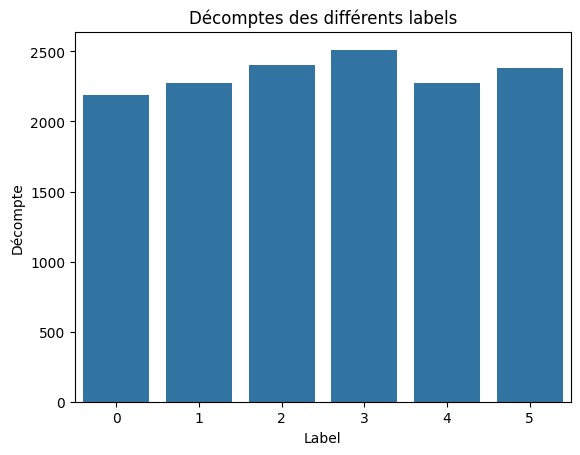

In [7]:
print(f"Forme des images : {images.shape}")
print(f"Forme des labels : {labels.shape}")

seaborn.countplot(x=labels.numpy())
plt.title("Décomptes des différents labels")
plt.ylabel("Décompte")
plt.xlabel("Label")
plt.show()

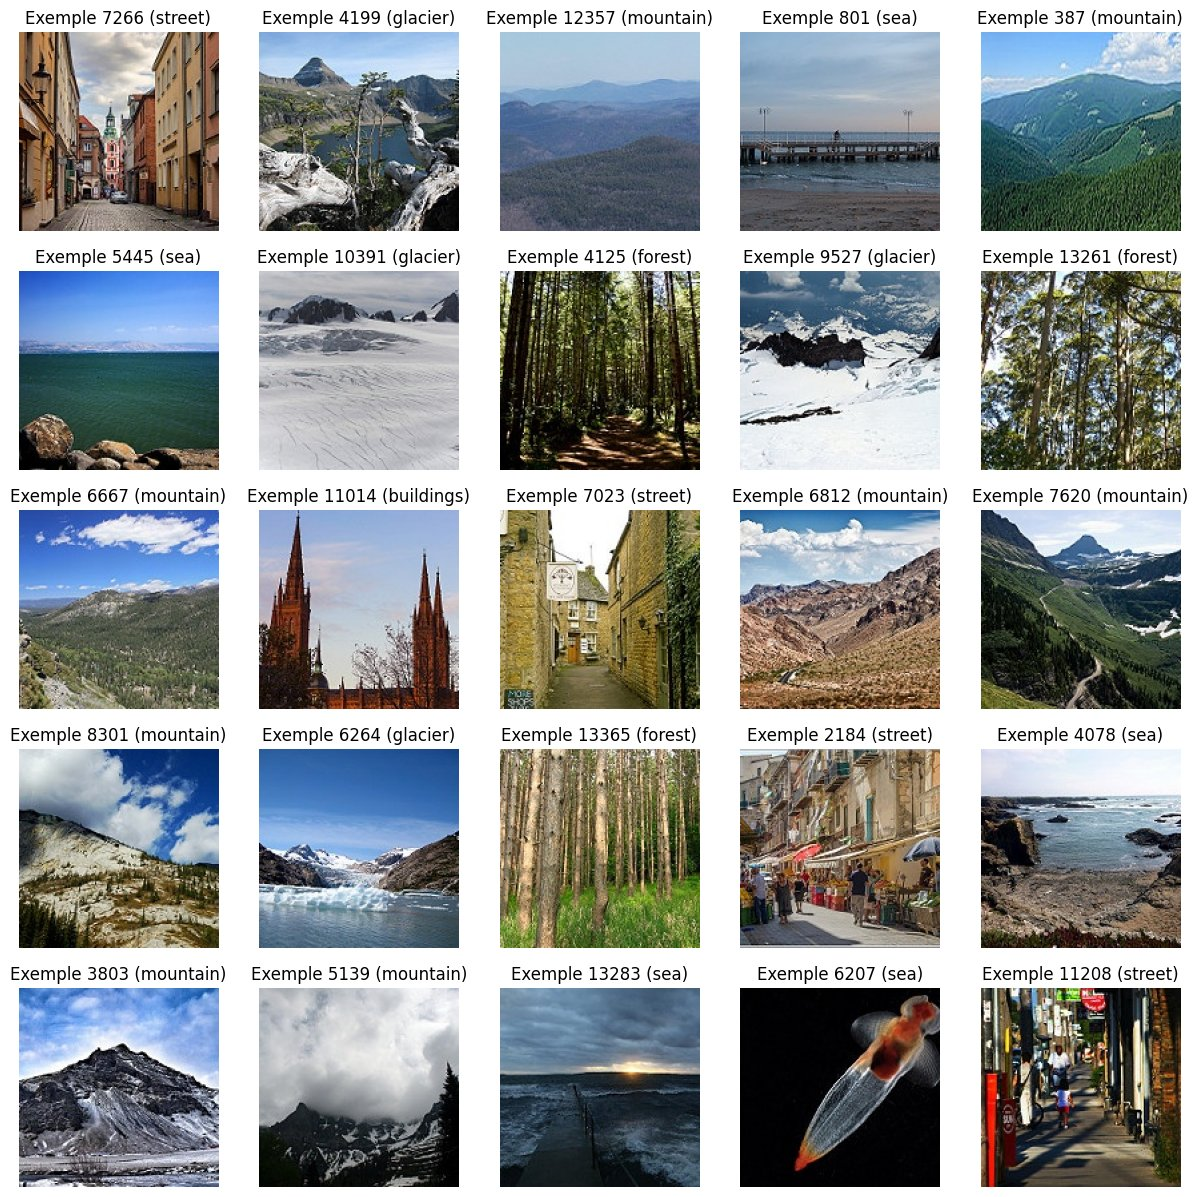

In [8]:
# Création de la grille de sous-plots. On donne l'argument figsize pour agrandir
# la taille de la figure qui est petite par défaut
f, ax = plt.subplots(5, 5, figsize=(15, 15))

# On choisit 25 indices au hasard, sans replacement (on ne veut pas afficher la
# même image deux fois)
random_indexes = numpy.random.choice(images.shape[0],
                                     size=(5, 5),
                                     replace=False)

for i in range(5):
  for j in range(5):
    img_index = random_indexes[i, j]
    image = images[img_index]
    label = label_names[labels[img_index]]

    # Affichage avec matplotlib et sa fonction imshow, très pratique en vision par
    # ordinateur
    ax[i, j].imshow(image)
    ax[i, j].set_title(f"Exemple {img_index} ({label})")
    ax[i, j].axis('off')

## Création du modèle

Voici un exemple de CNN « minimaliste »

In [9]:
# Initialisation et définition du modéle

# Le modèle est un empilement de couches où le flux de données est séquentiel
simple_cnn = keras.models.Sequential(name="simple_cnn")
simple_cnn.add(keras.layers.Input(shape=INPUT_SHAPE))
# Une première couche de 1 convolutions de 3x3 pixels
simple_cnn.add(keras.layers.Conv2D(1, kernel_size=(3, 3), activation="relu"))
# Une couche de max pooling
simple_cnn.add(keras.layers.MaxPool2D(3,3))

# Une couche de manipulation des tenseurs : suppression de toutes les dimensions
# sauf celle de batch et une autre qui contient toutes les valeurs
simple_cnn.add(keras.layers.Flatten())

# Une couche de sortie dense avec 6 neurones et un softmax comme activation
simple_cnn.add(keras.layers.Dense(6, activation="softmax"))

# Compilation du modèle avec la définition de la fonction de perte
simple_cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
                   loss="sparse_categorical_crossentropy",
                   metrics=["accuracy"])

# Affichage d'un résumé du modèle
simple_cnn.summary()

Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 1)    │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2401)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │        14,412 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,440 (56.41 KB)

 Trainable params: 14,440 (56.41 KB)

 Non-trainable params: 0 (0.00 B)

## Explication des différents nombres de paramètres

Premier layer de 1 convolutions : taille du kernel × nb kernel × nb canaux en entrée + nb biais (= nb kernel) = 3 × 3 × 1 × 3 + 1 = 28

Dernier layer dense : input dim × output dim + nb biais = 2401 × 6 + 6

## Apprentissage

Apprenons ce modèle sur nos données ! Dans un premier temps, nous entraînons sur une seule epoch pour simplement vérifier que notre modèle est opérationnel.

In [10]:
# Apprentissage du modèle
simple_cnn.fit(images, labels, epochs=1, validation_split=0.30)

307/307 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.2187 - loss: 74.4160 - val_accuracy: 0.2163 - val_loss: 47.4246


## Améliorons cette performance

In [11]:
CONV_LAYERS_NUMBER = 6
DENSE_LAYERS_SIZES = (200, 100, 50)


def conv() -> keras.layers.Conv2D:
  return keras.layers.Conv2D(filters=200,
                             kernel_size=(3,3),
                             activation="relu",
                             kernel_initializer="orthogonal",
                             padding="same")


def dense(size: int, activation: str = "relu") -> keras.layers.Dense:
  return keras.layers.Dense(size,
                            activation=activation,
                            kernel_initializer="orthogonal")


def dropout() -> keras.layers.Dropout:
  return keras.layers.Dropout(rate=0.2)


def max_pooling() -> keras.layers.MaxPooling2D:
  return keras.layers.MaxPooling2D(pool_size=(2, 2),
                                   strides=(2, 2),
                                   padding="same")


deep_cnn = keras.Sequential(name="deep_cnn")
deep_cnn.add(keras.layers.Input(shape=INPUT_SHAPE))

for _ in range(CONV_LAYERS_NUMBER - 1):
  deep_cnn.add(conv())
  deep_cnn.add(max_pooling())
deep_cnn.add(conv())

deep_cnn.add(keras.layers.Flatten())

for size in DENSE_LAYERS_SIZES:
  deep_cnn.add(dropout())
  deep_cnn.add(dense(size))

deep_cnn.add(dropout())
deep_cnn.add(dense(6, "softmax"))

deep_cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])

# Affichage d'un résumé du modèle
deep_cnn.summary()

Model: "deep_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 200)  │         5,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 75, 75, 200)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 200)    │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 38, 38, 200)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 38, 38, 200)    │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 19, 19, 200)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 19, 19, 200)    │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 10, 200)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 200)    │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 5, 5, 200)      │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │     1,000,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,832,256 (10.80 MB)

 Trainable params: 2,832,256 (10.80 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Visualisation des métriques d'entrainement
def plot_metrics(history) -> None:
  plt.plot(history["accuracy"])
  plt.plot(history["val_accuracy"])
  plt.title("Accuracy du modèle")
  plt.ylabel("Accuracy")
  plt.xlabel("Epoch")
  plt.legend(["Entraînement", "Validation"], loc="upper left")
  plt.show()

  plt.plot(history["loss"])
  plt.plot(history["val_loss"])
  plt.title("Perte du modèle")
  plt.ylabel("Perte")
  plt.xlabel("Epoch")
  plt.legend(["Entraînement", "Validation"], loc="upper right")
  plt.show()

Epoch 1/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.3906 - loss: 1.5597 - val_accuracy: 0.5782 - val_loss: 1.1034
Epoch 2/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 55s 716ms/step - accuracy: 0.5375 - loss: 1.1600 - val_accuracy: 0.6288 - val_loss: 0.9321
Epoch 3/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 55s 717ms/step - accuracy: 0.5932 - loss: 1.0574 - val_accuracy: 0.6673 - val_loss: 0.8783
Epoch 4/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 55s 718ms/step - accuracy: 0.6484 - loss: 0.9424 - val_accuracy: 0.7060 - val_loss: 0.7746
Epoch 5/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 55s 719ms/step - accuracy: 0.6847 - loss: 0.8543 - val_accuracy: 0.7545 - val_loss: 0.6917
Epoch 6/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 55s 718ms/step - accuracy: 0.7197 - loss: 0.7840 - val_accuracy: 0.7457 - val_loss: 0.6652
Epoch 7/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 55s 721ms/step - accuracy: 0.7511 - loss: 0.7108 - val_accuracy: 0.7706 - val_loss: 0.6365
Epoch 8/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 56s 723ms/step - accuracy: 0.7775 - loss: 0.6495 - val_accura

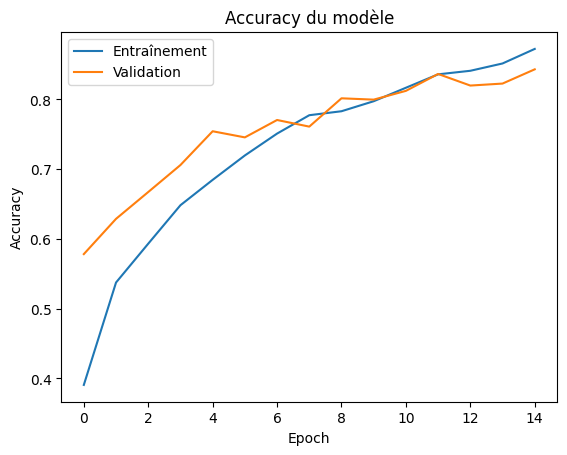

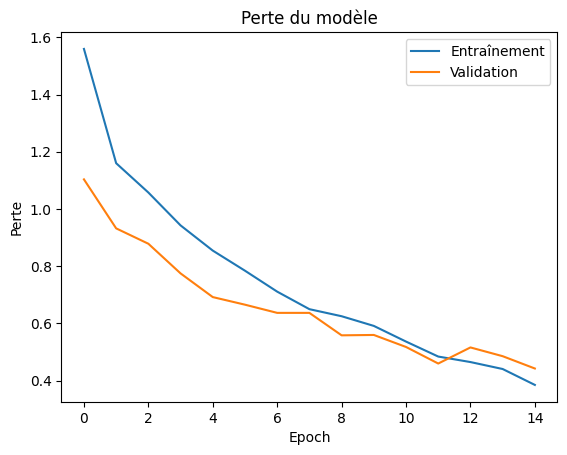

In [13]:
# Apprentissage du modèle

BEST_DEEP_MODEL_PATH = "best_deep_model.weights.h5"

early_stopping = keras.callbacks.EarlyStopping(
    patience=5,
    monitor="val_loss")

model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=BEST_DEEP_MODEL_PATH,
    monitor="val_accuracy",
    mode="max",
    save_weights_only=True,
    save_best_only=True)

training = deep_cnn.fit(images,
                        labels,
                        epochs=DEEP_CNN_EPOCHS,
                        validation_split=0.30,
                        batch_size=128,
                        callbacks=[early_stopping, model_checkpoint])

deep_cnn.load_weights(BEST_DEEP_MODEL_PATH)

plot_metrics(training.history)

## Évaluation des performances sur l'ensemble de test

Dans le dossier `seg_test` se trouve un ensemble de données qui n'ont jamais été vues durant l'apprentissage.

On utilisera la méthode `evaluate(X, y)` du modèle pour évaluer la qualité de nos prédictions sur ce dataset.

In [14]:
test_images,test_labels = get_images(
    pathlib.Path("landscape") / "seg_test")
loss, accuracy = deep_cnn.evaluate(test_images, test_labels, verbose=False)
print(f"Loss: {loss:.2f}, accuracy: {accuracy:.2f}")

Traitement des dossiers:   0%|          | 0/6 [00:00<?, ?it/s]

Dossier buildings:   0%|          | 0/437 [00:00<?, ?it/s]

Dossier forest:   0%|          | 0/474 [00:00<?, ?it/s]

Dossier glacier:   0%|          | 0/553 [00:00<?, ?it/s]

Dossier mountain:   0%|          | 0/525 [00:00<?, ?it/s]

Dossier sea:   0%|          | 0/510 [00:00<?, ?it/s]

Dossier street:   0%|          | 0/501 [00:00<?, ?it/s]

Loss: 0.44, accuracy: 0.85


## Analyse d'erreur

On affiche la matrice de confusion puis on regarde des images mal classées.

In [15]:
def predict(model: keras.Model, images: tf.Tensor) -> tf.Tensor:
  return tf.math.argmax(model.predict(images), axis=-1)


def analyze_preds(preds: tf.Tensor, labels: tf.Tensor) -> None:
  confusion_matrix = sklearn.metrics.confusion_matrix(labels, preds)
  seaborn.heatmap(confusion_matrix,
                  cmap="rocket_r",
                  xticklabels=label_names,
                  yticklabels=label_names,
                  annot=True,
                  fmt="d")
  plt.title("Matrice de confusion")
  plt.show()

  seaborn.countplot(x=[label_names[x] for x in preds])
  plt.title("Décomptes des classes prédites")
  plt.ylabel("Décompte")
  plt.xlabel("Class")
  plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step


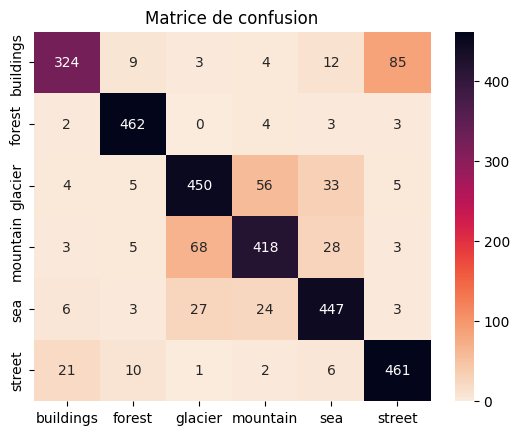

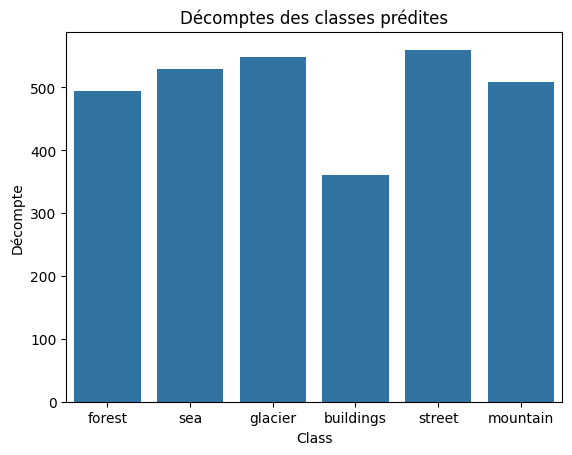

In [16]:
test_preds = predict(deep_cnn, test_images)
analyze_preds(test_preds, test_labels)

In [17]:
def plot_mistakes(predicted_class: str,
                  true_class: str,
                  images: tf.Tensor,
                  preds: tf.Tensor,
                  labels: tf.Tensor
                  ) -> None:
  print(f"Prédiction : {predicted_class}, classe réelle : {true_class}")
  mistakes = images[(preds == label_to_index[predicted_class])
                         & (labels == label_to_index[true_class])]
  random_indexes = numpy.random.choice(mistakes.shape[0],
                                       size=min(mistakes.shape[0], 25),
                                       replace=False)
  grid_indexes = itertools.product(range(5), repeat=2)

  if mistakes.shape[1] == 3:
    mistakes = tf.transpose(mistakes, perm=(0, 2, 3, 1))

  _, ax = plt.subplots(5, 5, figsize=(15, 15))
  for img_index, (i, j) in zip(random_indexes, grid_indexes):
    ax[i, j].imshow(mistakes[img_index])
    ax[i, j].axis("off")
  plt.show()

Prédiction : glacier, classe réelle : mountain


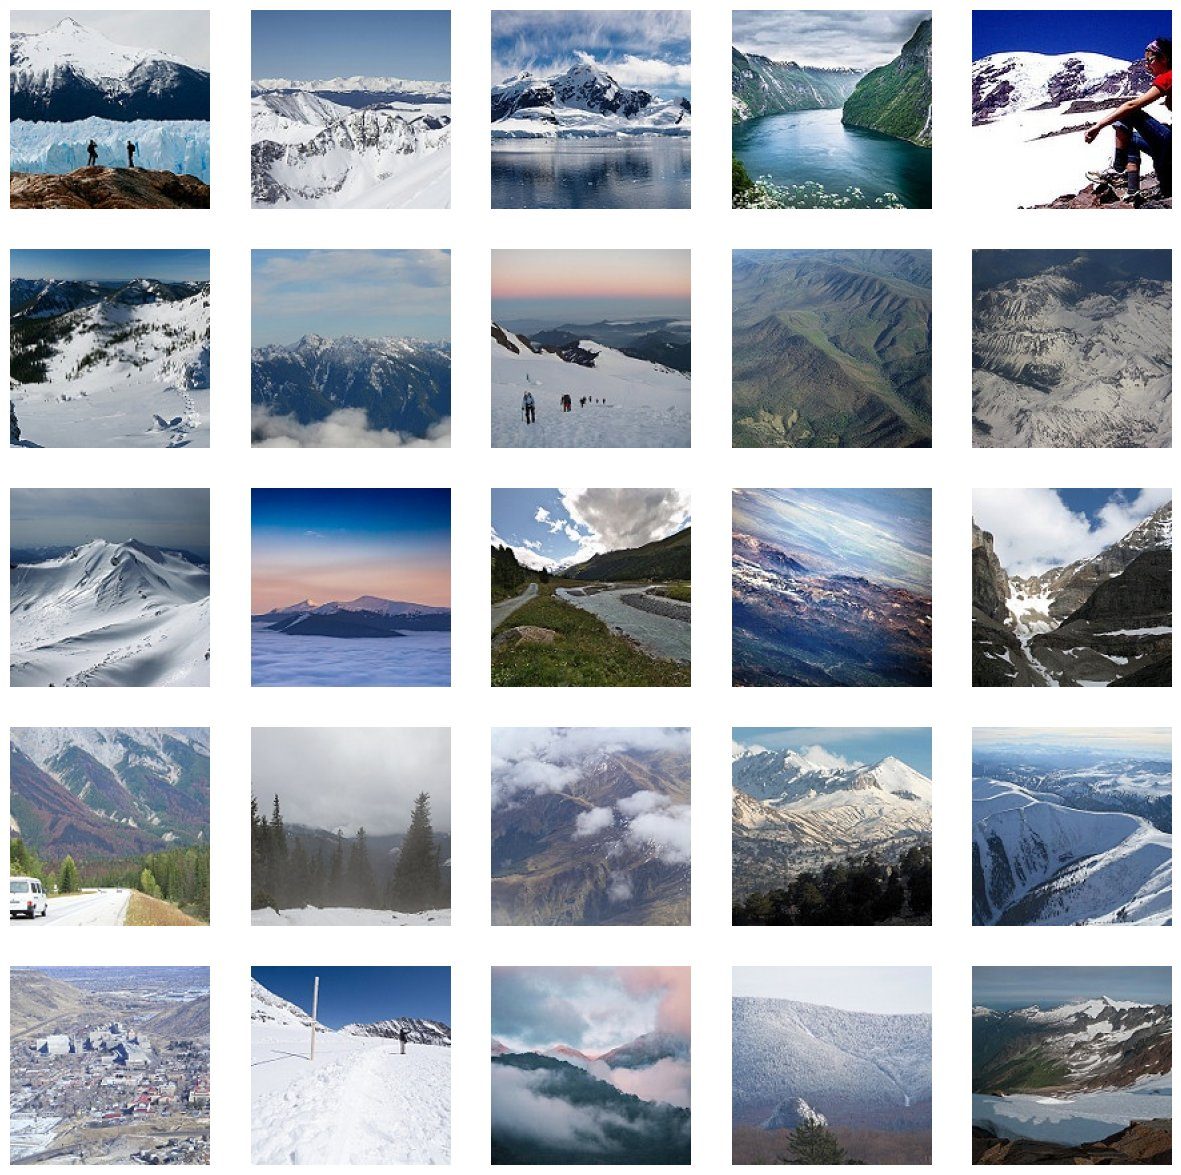

In [18]:
# Plot les images prédites glacier alors qu'elles ont un label montagne
plot_mistakes("glacier", "mountain", test_images, test_preds, test_labels)

Prédiction : glacier, classe réelle : sea


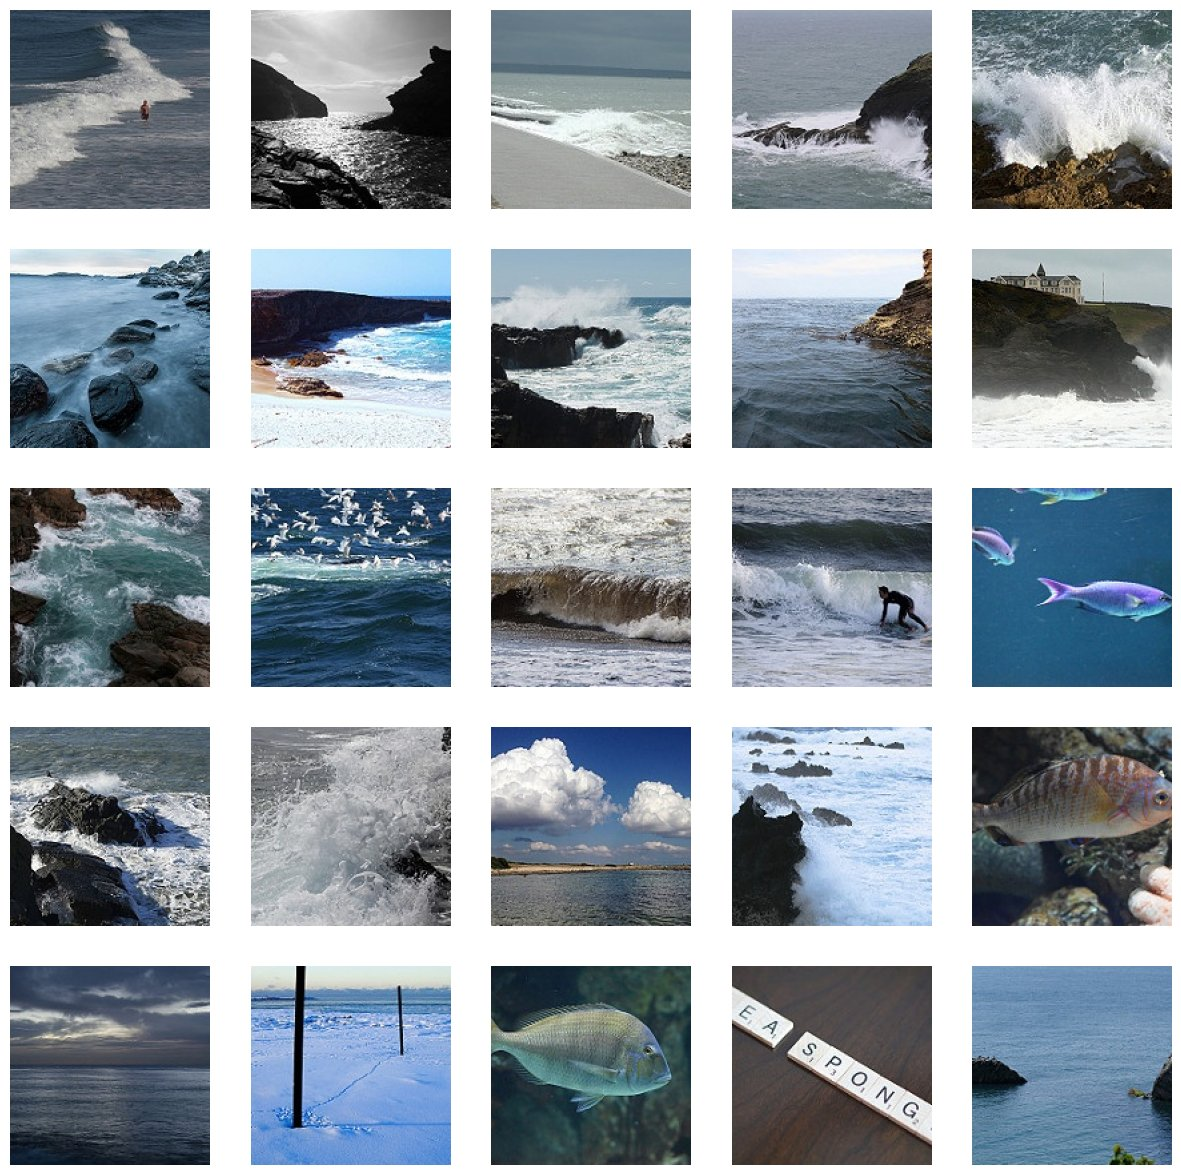

In [19]:
# Plot les images prédites glacier alors qu'elles ont un label mer
plot_mistakes("glacier", "sea", test_images, test_preds, test_labels)

Prédiction : buildings, classe réelle : sea


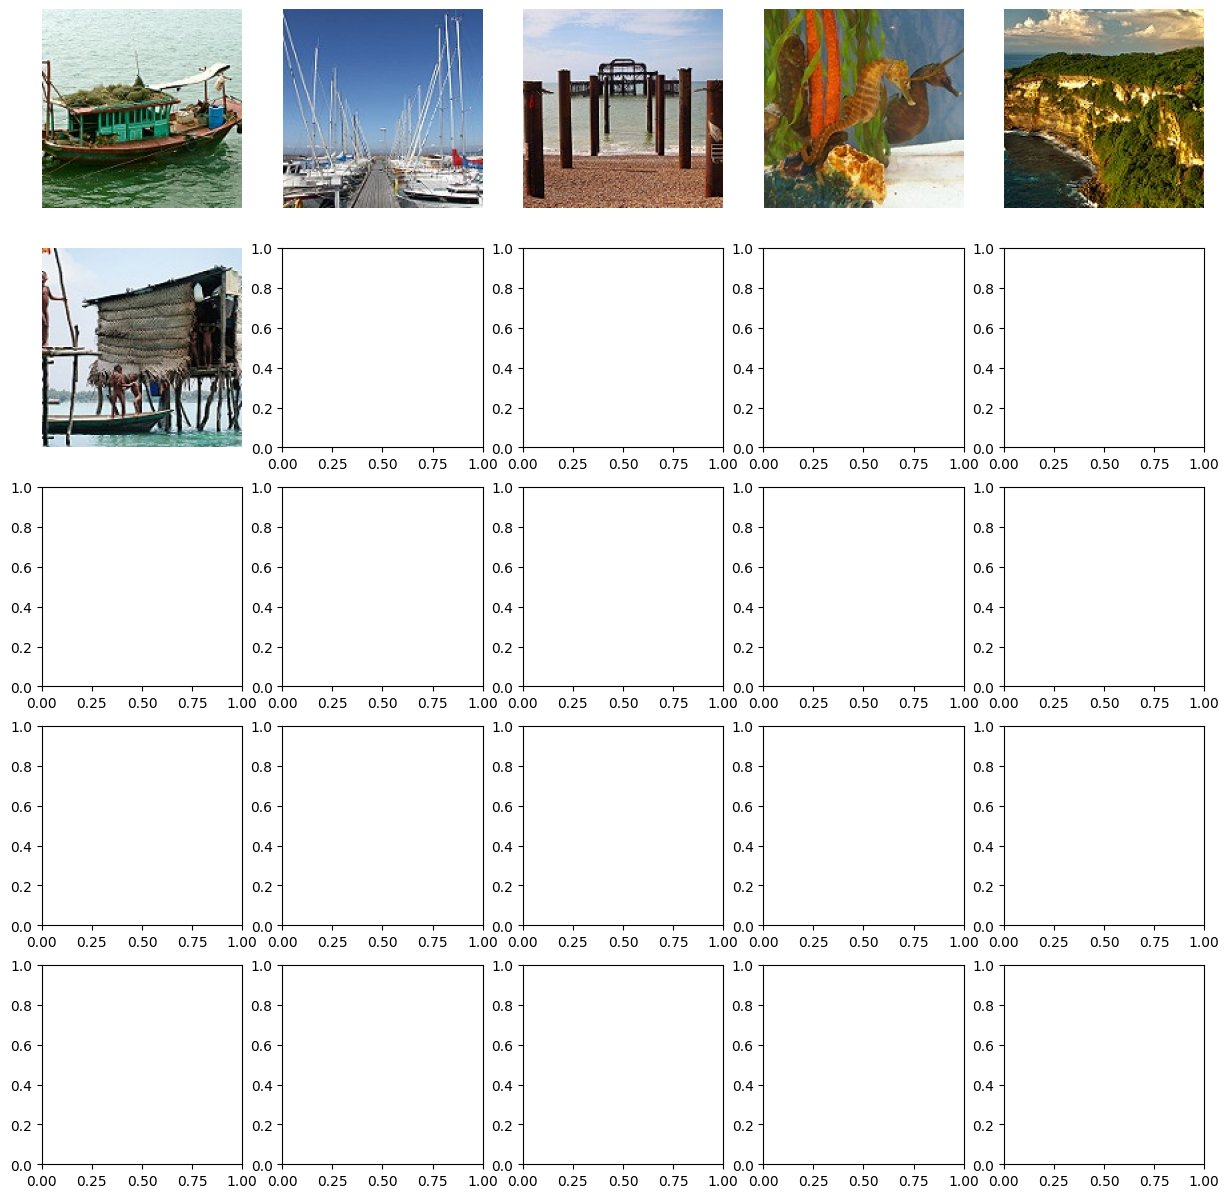

In [20]:
# Plot les images prédites bâtiment alors qu'elles ont un label mer
plot_mistakes("buildings", "sea", test_images, test_preds, test_labels)

In [21]:
def evaluate(model: keras.Model, images: tf.Tensor, labels: tf.Tensor) -> None:
  loss, accuracy = model.evaluate(images, labels, verbose=False)
  print(f"Loss: {loss:.2f}, accuracy: {accuracy:.2f}")
  preds = predict(model, images)
  analyze_preds(preds, labels)
  plot_mistakes("glacier", "mountain", images, preds, labels)
  plot_mistakes("glacier", "sea", images, preds, labels)
  plot_mistakes("buildings", "sea", images, preds, labels)

Loss: 0.44, accuracy: 0.85
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step


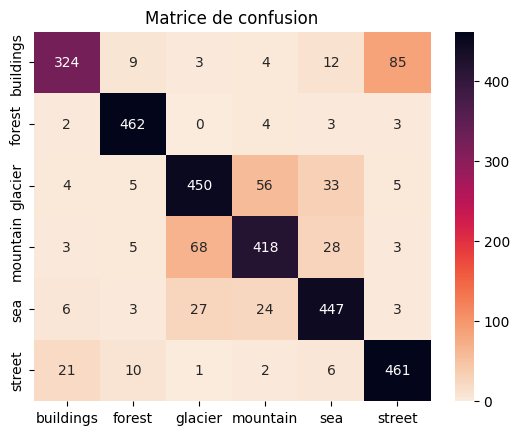

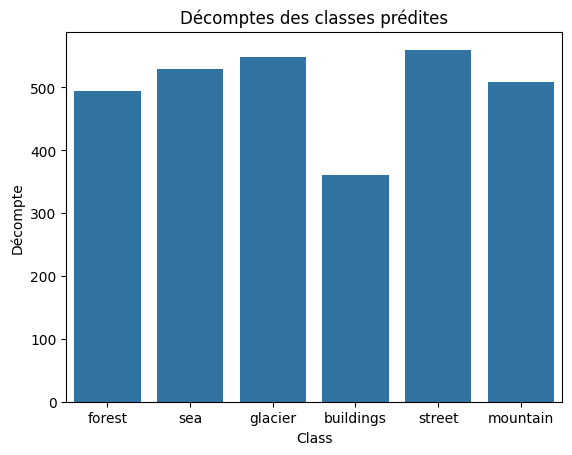

Prédiction : glacier, classe réelle : mountain


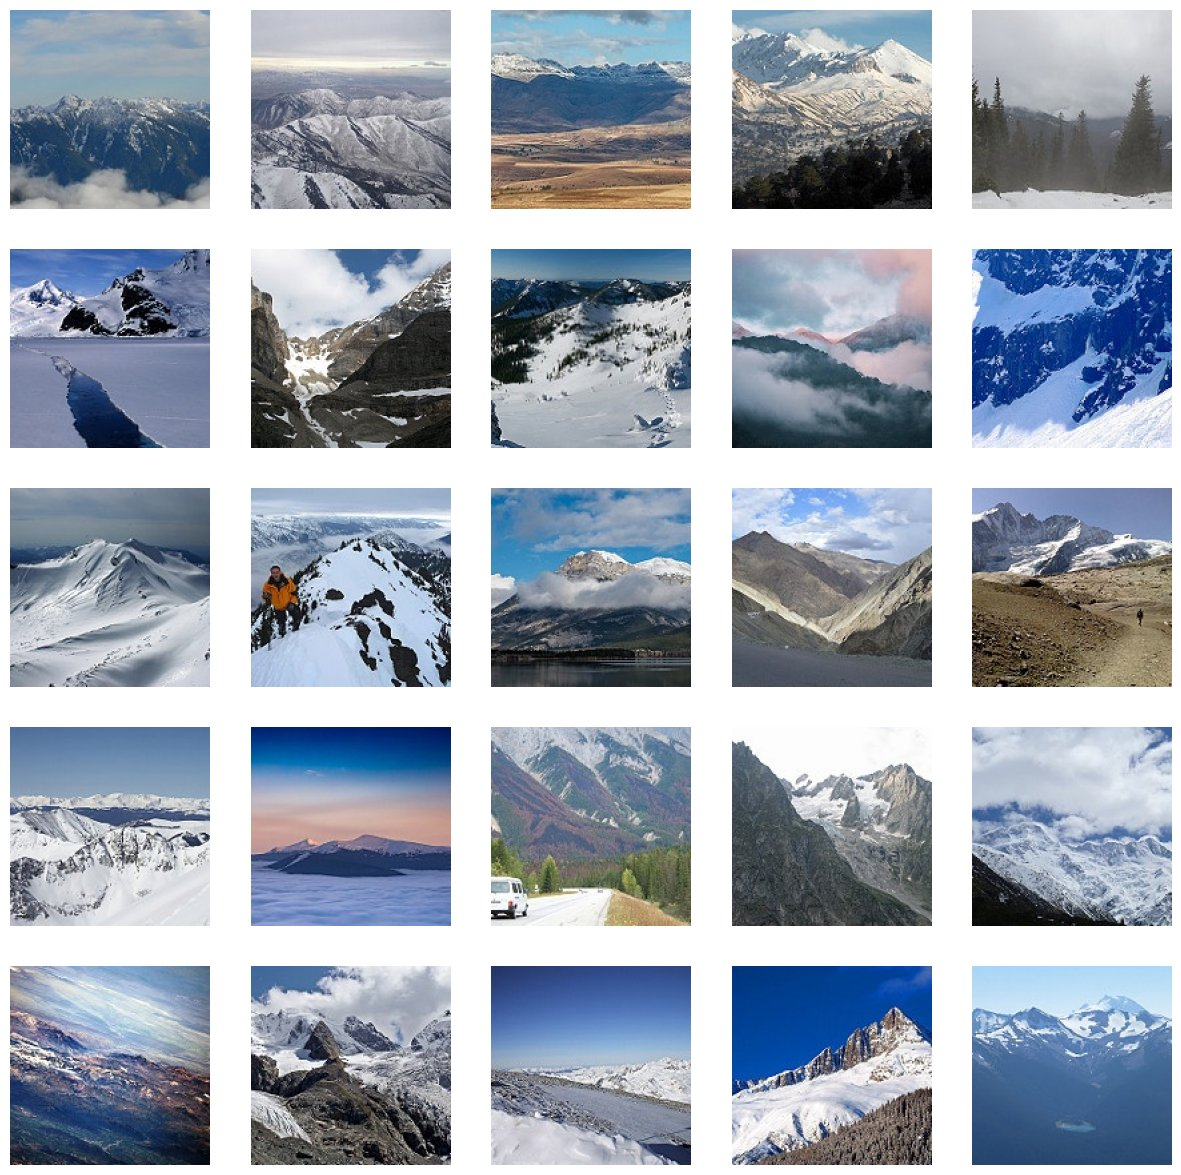

Prédiction : glacier, classe réelle : sea


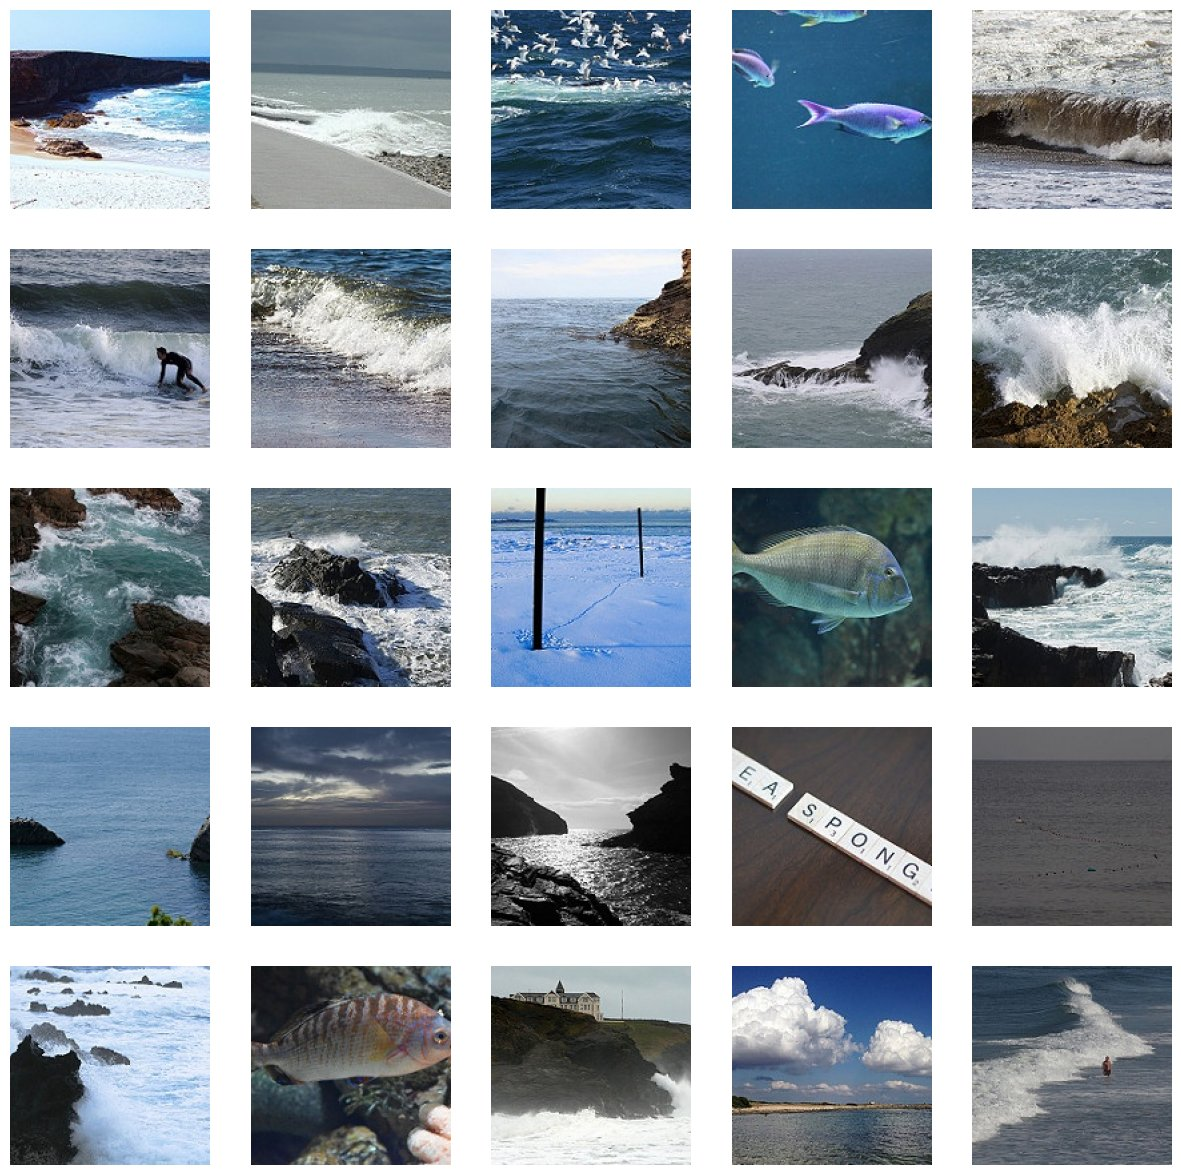

Prédiction : buildings, classe réelle : sea


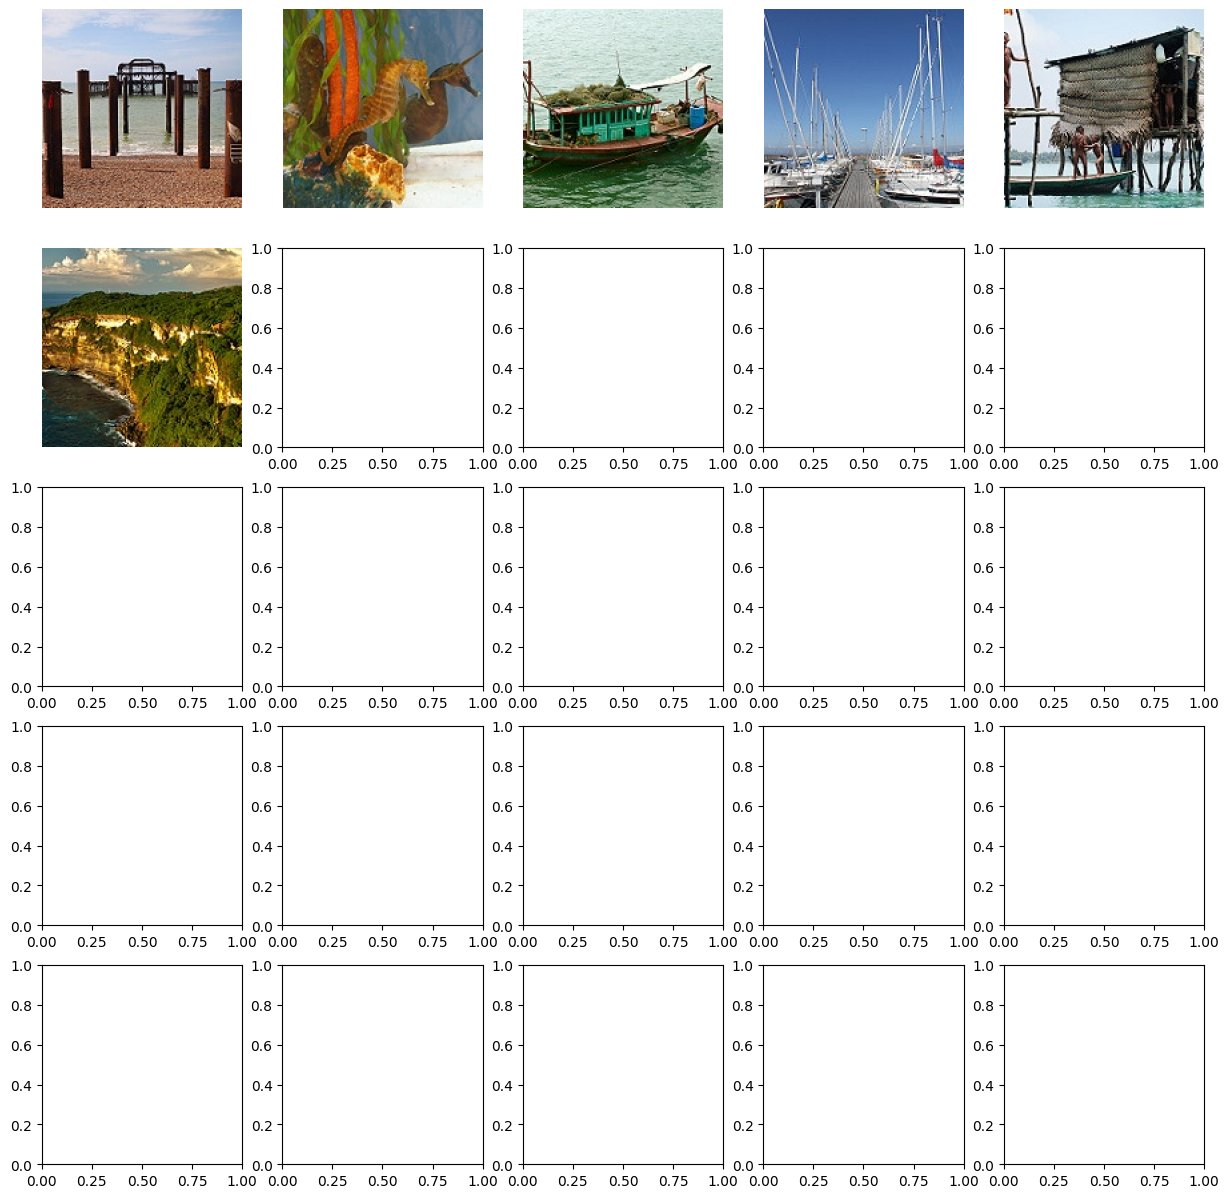

In [22]:
evaluate(deep_cnn, test_images, test_labels)

## Transfert d'apprentissage

In [23]:
base_model = keras.applications.EfficientNetV2B0(include_top=False,
                                                 weights="imagenet",
                                                 input_shape=(150, 150, 3))

base_model.trainable = False

transferred_cnn = keras.Sequential(
    [base_model,
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Conv2D(1024, 1, activation="relu"),
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Conv2D(256, 1, activation="relu"),
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Conv2D(64, 1, activation="relu"),
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Conv2D(16, 1, activation="relu"),
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Flatten(),
     keras.layers.Dense(6, activation="softmax", kernel_regularizer="l2")],
    name="transferred_cnn")

transferred_cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
                        loss="sparse_categorical_crossentropy",
                        metrics=["accuracy"])

transferred_cnn.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "transferred_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 5, 5, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 5, 5, 1280)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 5, 5, 1024)     │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 5, 5, 1024)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 5, 5, 256)      │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 5, 5, 256)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 5, 5, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_3             │ (None, 5, 5, 64)       │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 5, 5, 16)       │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_4             │ (None, 5, 5, 16)       │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         2,406 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,513,350 (28.66 MB)

 Trainable params: 1,594,038 (6.08 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [24]:
training = transferred_cnn.fit(images,
                               labels,
                               epochs=5,
                               validation_split=0.30,
                               batch_size=512)

Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - accuracy: 0.3821 - loss: 1.6840 - val_accuracy: 0.6768 - val_loss: 1.1866
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 62s 297ms/step - accuracy: 0.6755 - loss: 1.0620 - val_accuracy: 0.8352 - val_loss: 0.6963
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 297ms/step - accuracy: 0.7923 - loss: 0.7326 - val_accuracy: 0.8734 - val_loss: 0.5046
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 296ms/step - accuracy: 0.8321 - loss: 0.5946 - val_accuracy: 0.8858 - val_loss: 0.4396
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 346ms/step - accuracy: 0.8600 - loss: 0.5165 - val_accuracy: 0.8950 - val_loss: 0.4105


Loss: 0.41, accuracy: 0.90
94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 83ms/step


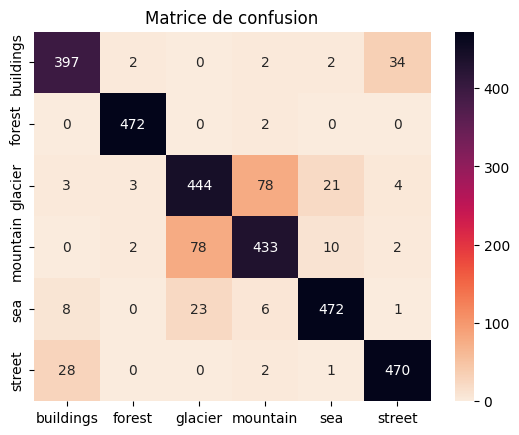

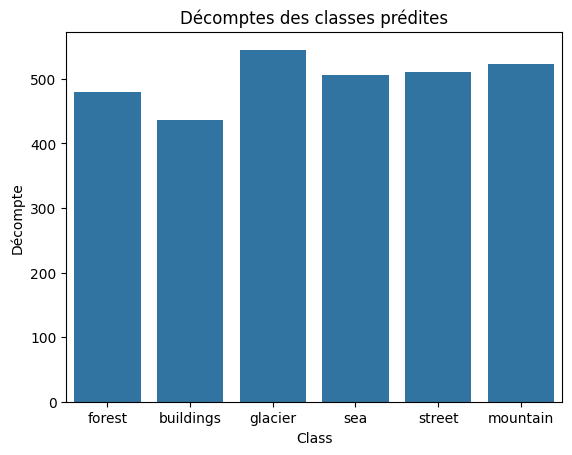

Prédiction : glacier, classe réelle : mountain


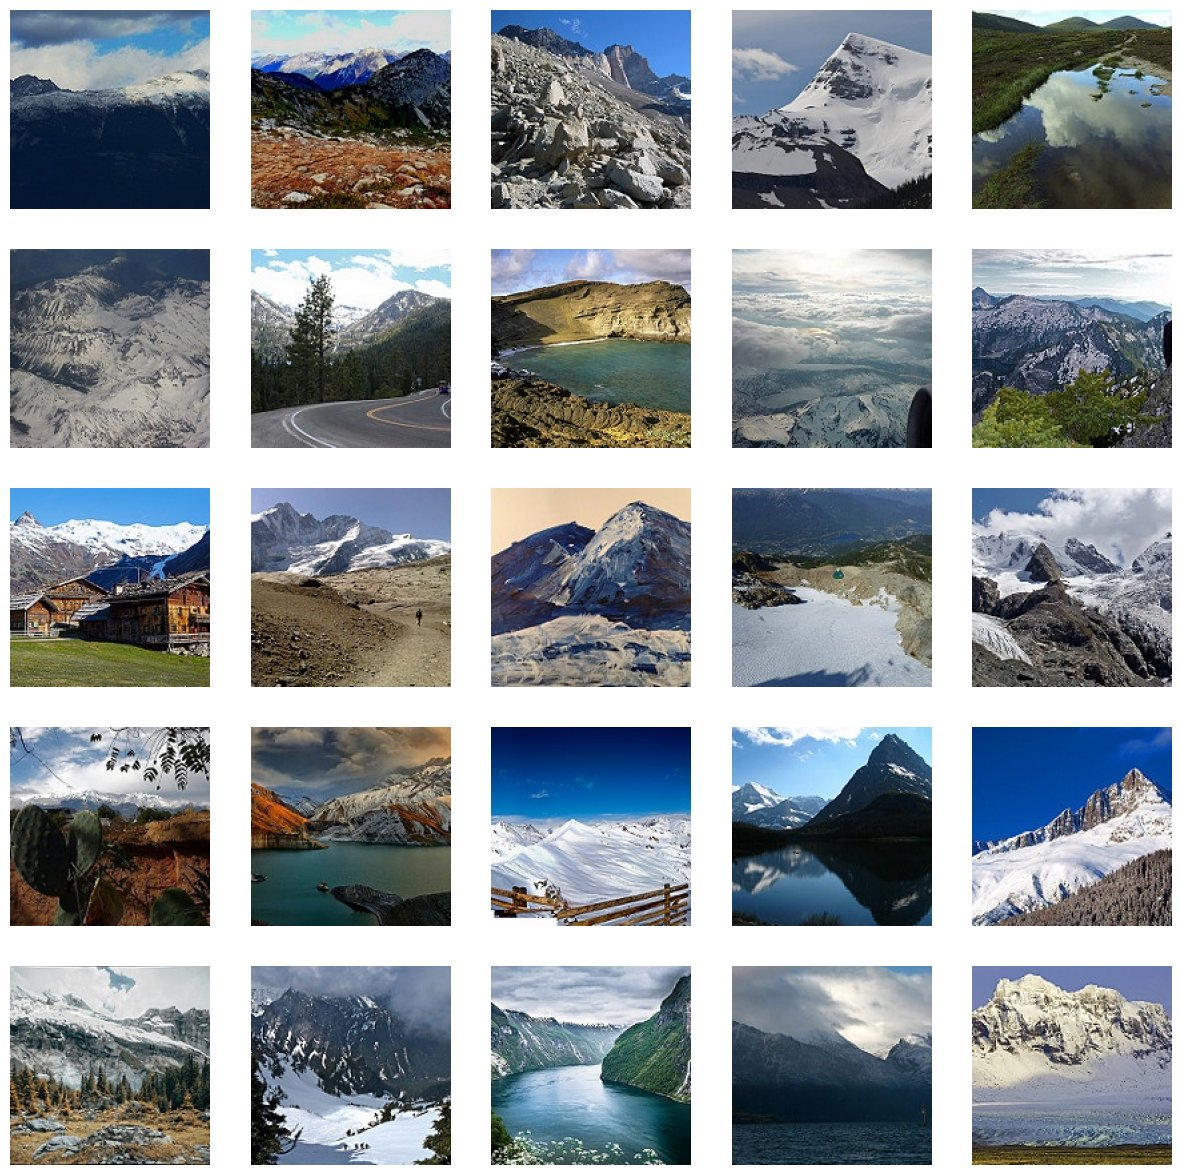

Prédiction : glacier, classe réelle : sea


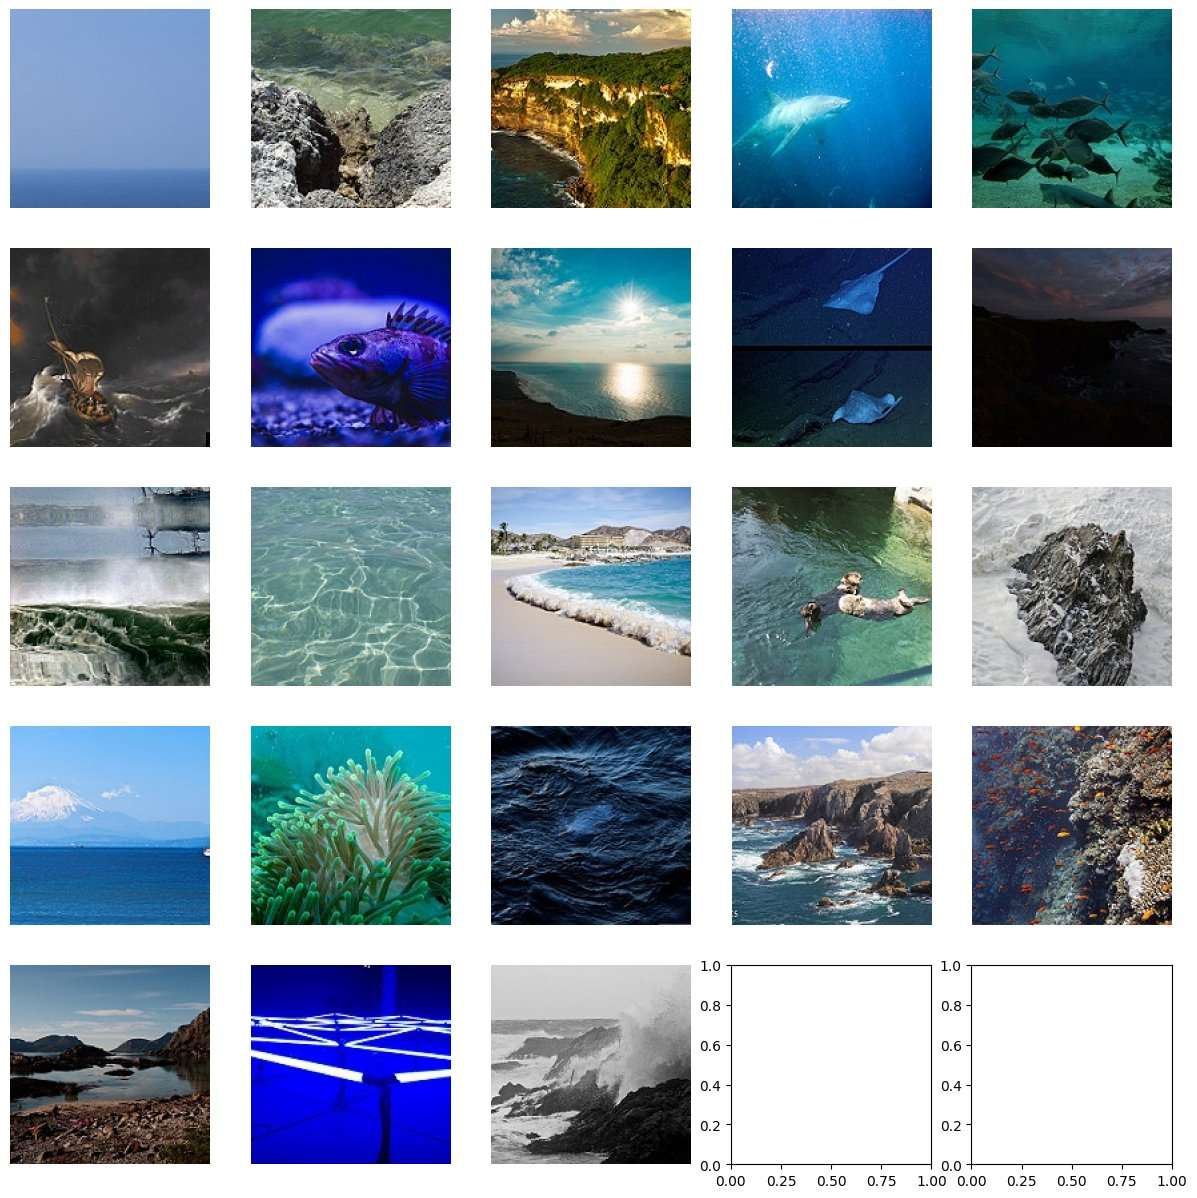

Prédiction : buildings, classe réelle : sea


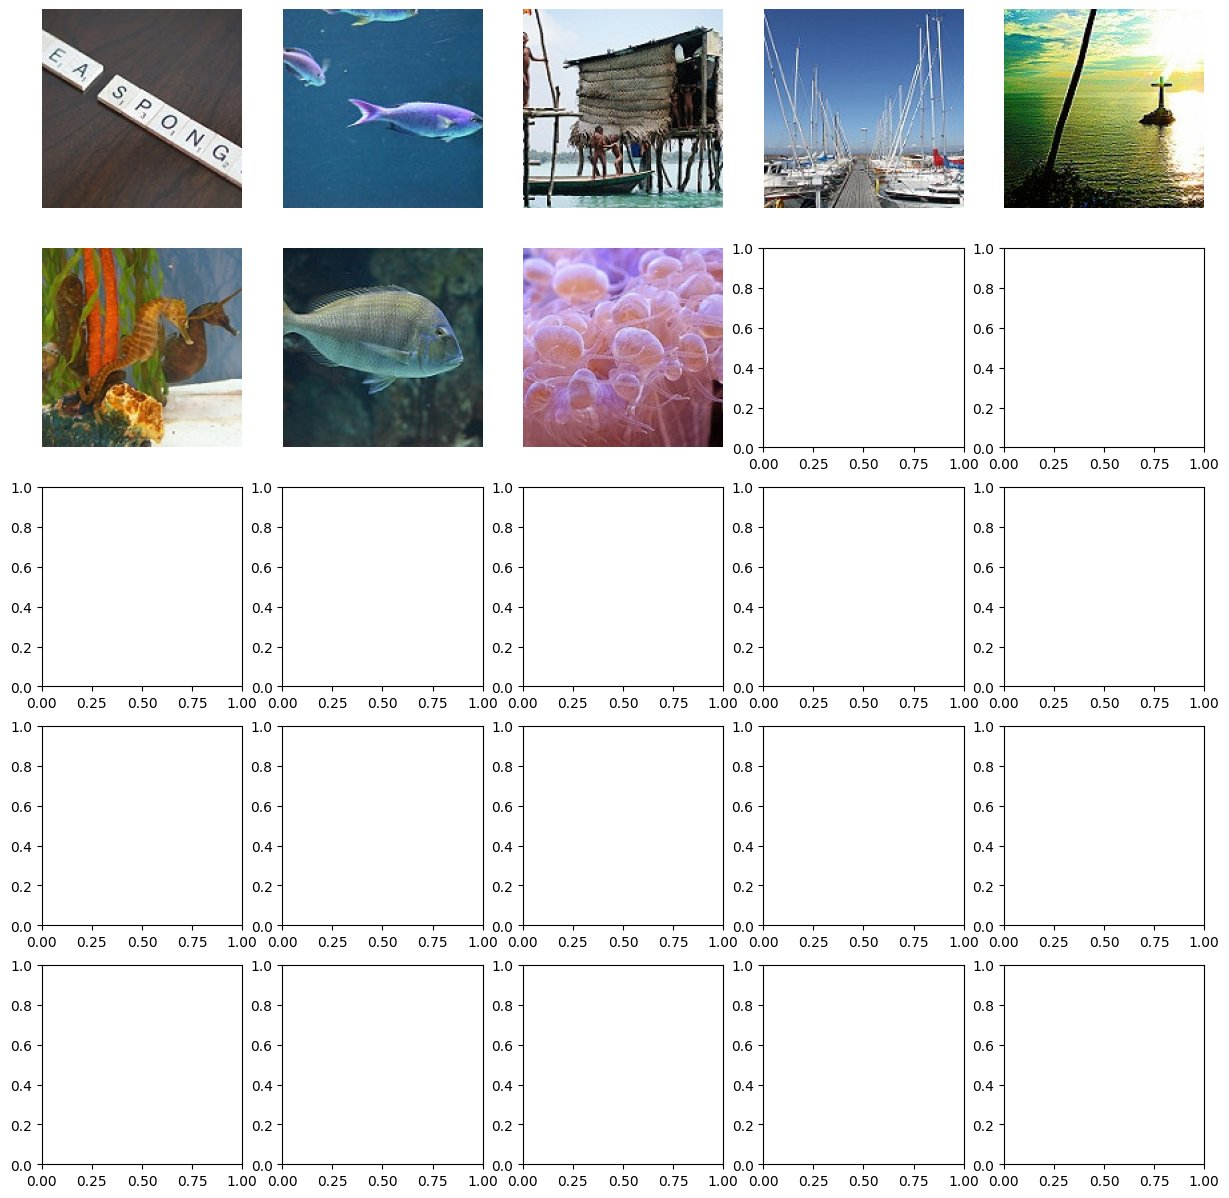

In [25]:
evaluate(transferred_cnn, test_images, test_labels)

## Avec les transformeurs pour la vision par ordinateur (ViT)

In [26]:
!pip install 'transformers < 5'

In [27]:
images, labels = get_images(pathlib.Path("landscape") / "seg_train",
                            size=224,
                            channels_first=True)

Traitement des dossiers:   0%|          | 0/6 [00:00<?, ?it/s]

Dossier buildings:   0%|          | 0/2191 [00:00<?, ?it/s]

Dossier forest:   0%|          | 0/2271 [00:00<?, ?it/s]

Dossier glacier:   0%|          | 0/2404 [00:00<?, ?it/s]

Dossier mountain:   0%|          | 0/2512 [00:00<?, ?it/s]

Dossier sea:   0%|          | 0/2274 [00:00<?, ?it/s]

Dossier street:   0%|          | 0/2382 [00:00<?, ?it/s]

In [28]:
import transformers


vit = transformers.TFAutoModel.from_pretrained(
    "google/vit-base-patch16-224-in21k", use_safetensors=False)

vit.trainable = False
inputs = keras.layers.Input((3, 224, 224))
x = keras.layers.Lambda(lambda t: t / 255)(inputs)
x = keras.layers.Normalization(mean=0.5, variance=0.5 ** 2)(x)

# Wrap the vit model call in a Lambda layer to handle the tensor type issue
x = keras.layers.Lambda(lambda x: vit(x).last_hidden_state)(x)

x = keras.layers.Dense(128, activation="relu")(x)
x = keras.layers.Dense(64, activation="relu")(x)
x = keras.layers.Dense(32, activation="relu")(x)
x = keras.layers.Flatten()(x)
outputs = keras.layers.Dense(6, activation="softmax")(x)
transferred_transformer = keras.Model(inputs=inputs,
                                      outputs=outputs,
                                      name="transferred_transformer")
transferred_transformer.compile(optimizer="adam",
                                metrics=["accuracy"],
                                loss="sparse_categorical_crossentropy")
transferred_transformer.summary()

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/346M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All model checkpoint layers were used when initializing TFViTModel.

All the layers of TFViTModel were initialized from the model checkpoint at google/vit-base-patch16-224-in21k.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTModel for predictions without further training.


Model: "transferred_transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 3, 224, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 3, 224, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 3, 224, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 197, 768)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 197, 128)       │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 197, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 197, 32)        │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │        37,830 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,598 (572.65 KB)

 Trainable params: 146,598 (572.65 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
transferred_transformer.fit(images, labels, epochs=VIT_EPOCHS, validation_split=0.3, batch_size=512)

Epoch 1/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 188s 8s/step - accuracy: 0.8165 - loss: 0.5714 - val_accuracy: 0.9223 - val_loss: 0.2594
Epoch 2/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 134s 7s/step - accuracy: 0.9401 - loss: 0.1896 - val_accuracy: 0.9385 - val_loss: 0.1991
Epoch 3/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 135s 7s/step - accuracy: 0.9550 - loss: 0.1280 - val_accuracy: 0.9456 - val_loss: 0.1630


Traitement des dossiers:   0%|          | 0/6 [00:00<?, ?it/s]

Dossier buildings:   0%|          | 0/437 [00:00<?, ?it/s]

Dossier forest:   0%|          | 0/474 [00:00<?, ?it/s]

Dossier glacier:   0%|          | 0/553 [00:00<?, ?it/s]

Dossier mountain:   0%|          | 0/525 [00:00<?, ?it/s]

Dossier sea:   0%|          | 0/510 [00:00<?, ?it/s]

Dossier street:   0%|          | 0/501 [00:00<?, ?it/s]

Loss: 0.17, accuracy: 0.94
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 402ms/step


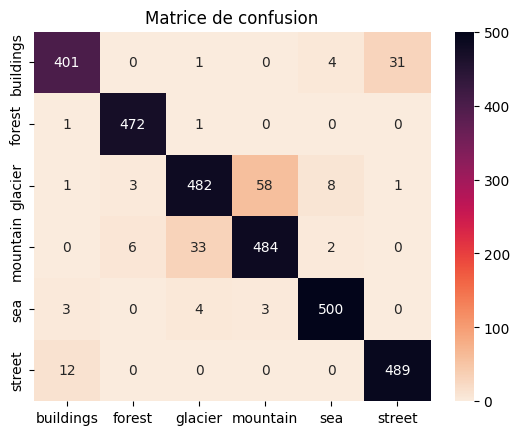

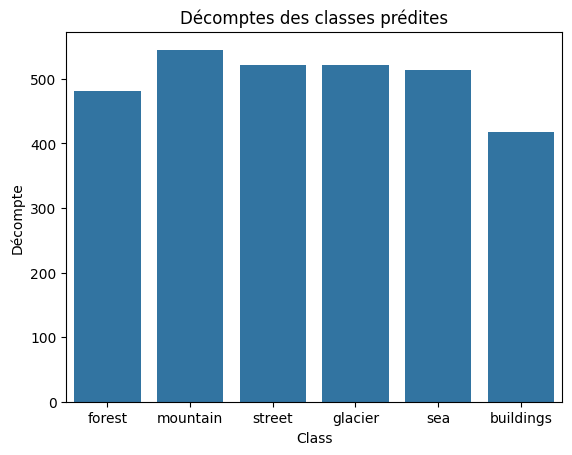

Prédiction : glacier, classe réelle : mountain


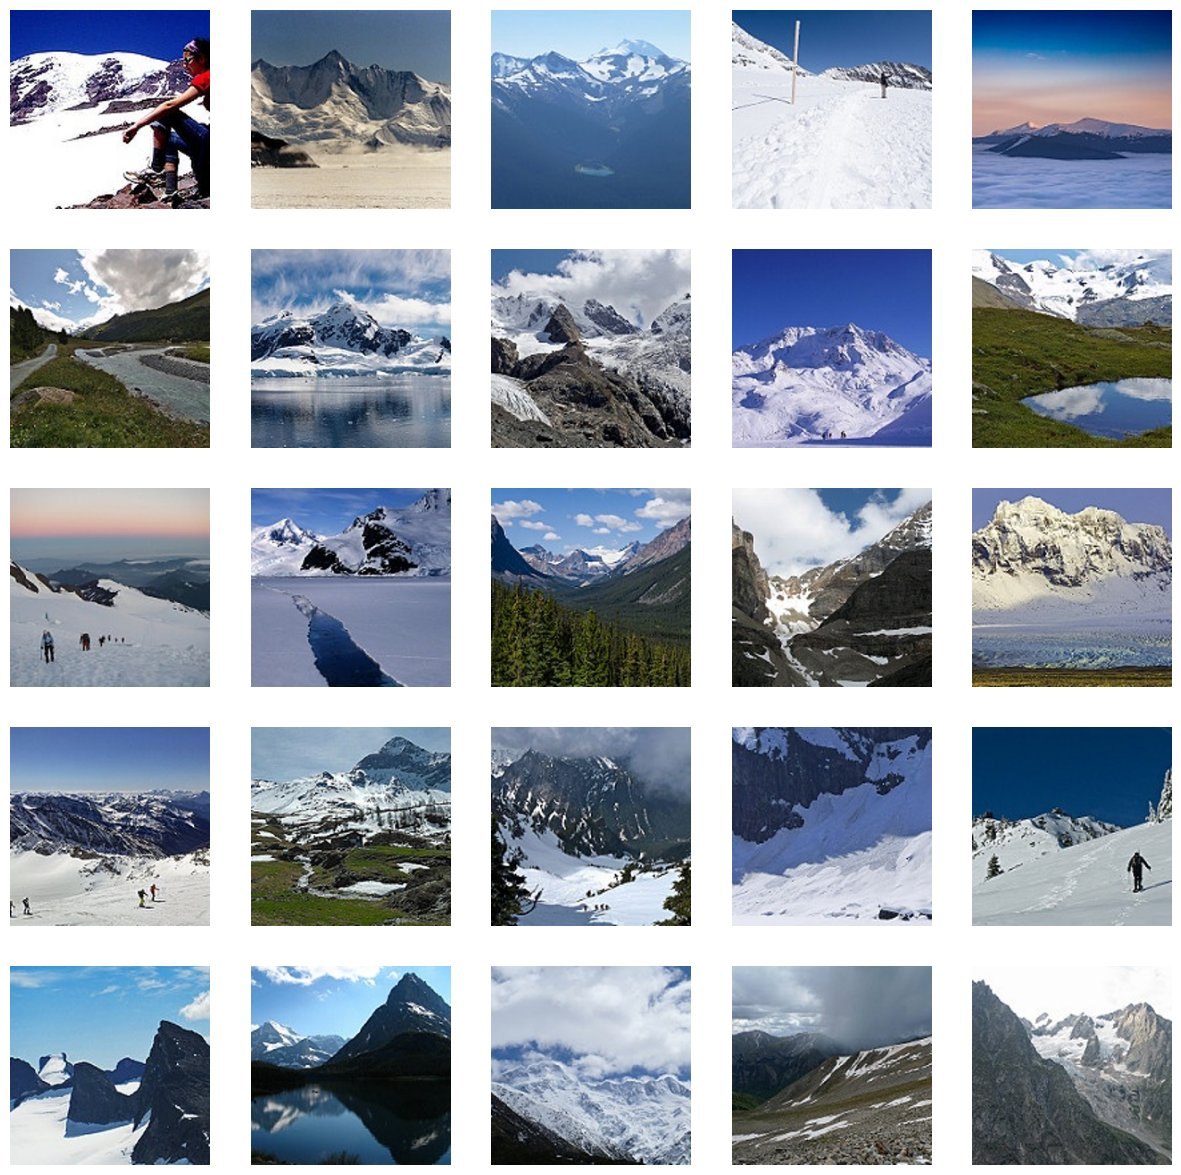

Prédiction : glacier, classe réelle : sea


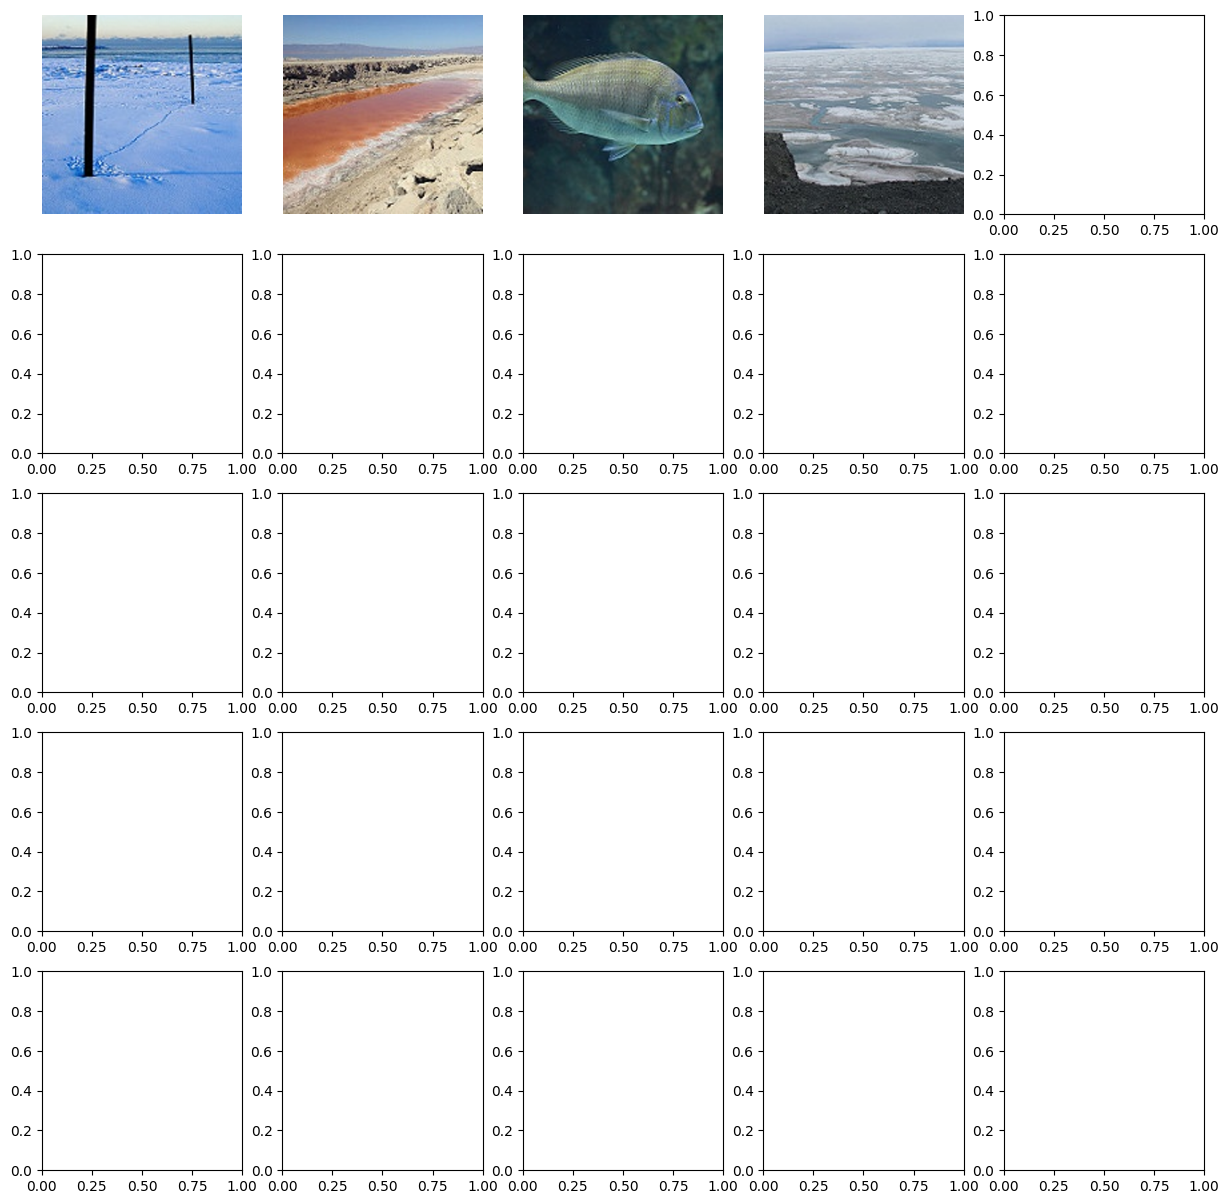

Prédiction : buildings, classe réelle : sea


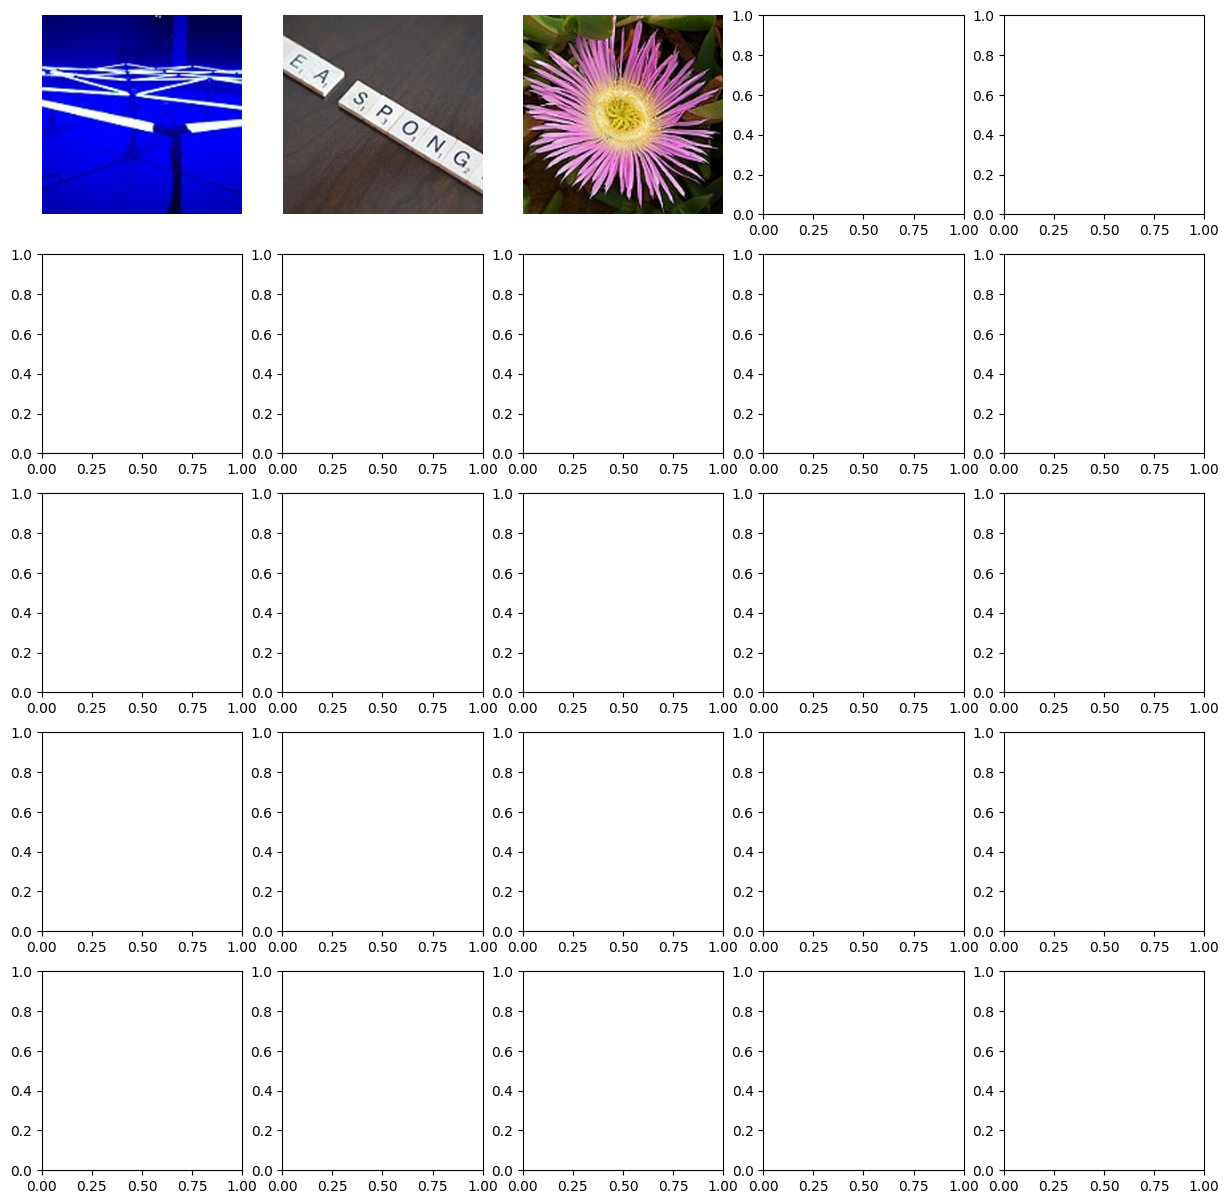

In [30]:
test_images, test_labels = get_images(
    pathlib.Path("landscape") / "seg_test",
    size=224,
    channels_first=True)
evaluate(transferred_transformer, test_images, test_labels)

## Prédire dans des condition « réelles »

Dans le dossier `seg_pred` se trouvent des images non-annotées. On ne peut donc pas évaluer correctement les performances sur cet ensemble.

Cependant, on peut afficher des photos et les probabilités que notre modèle attribue à chaque classe.

In [31]:
pred_images = get_images(
    pathlib.Path("landscape") / "seg_pred",
    size=224,
    channels_first=True,
    create_labels=False)

Traitement des dossiers:   0%|          | 0/1 [00:00<?, ?it/s]

Dossier no_supervision:   0%|          | 0/7301 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


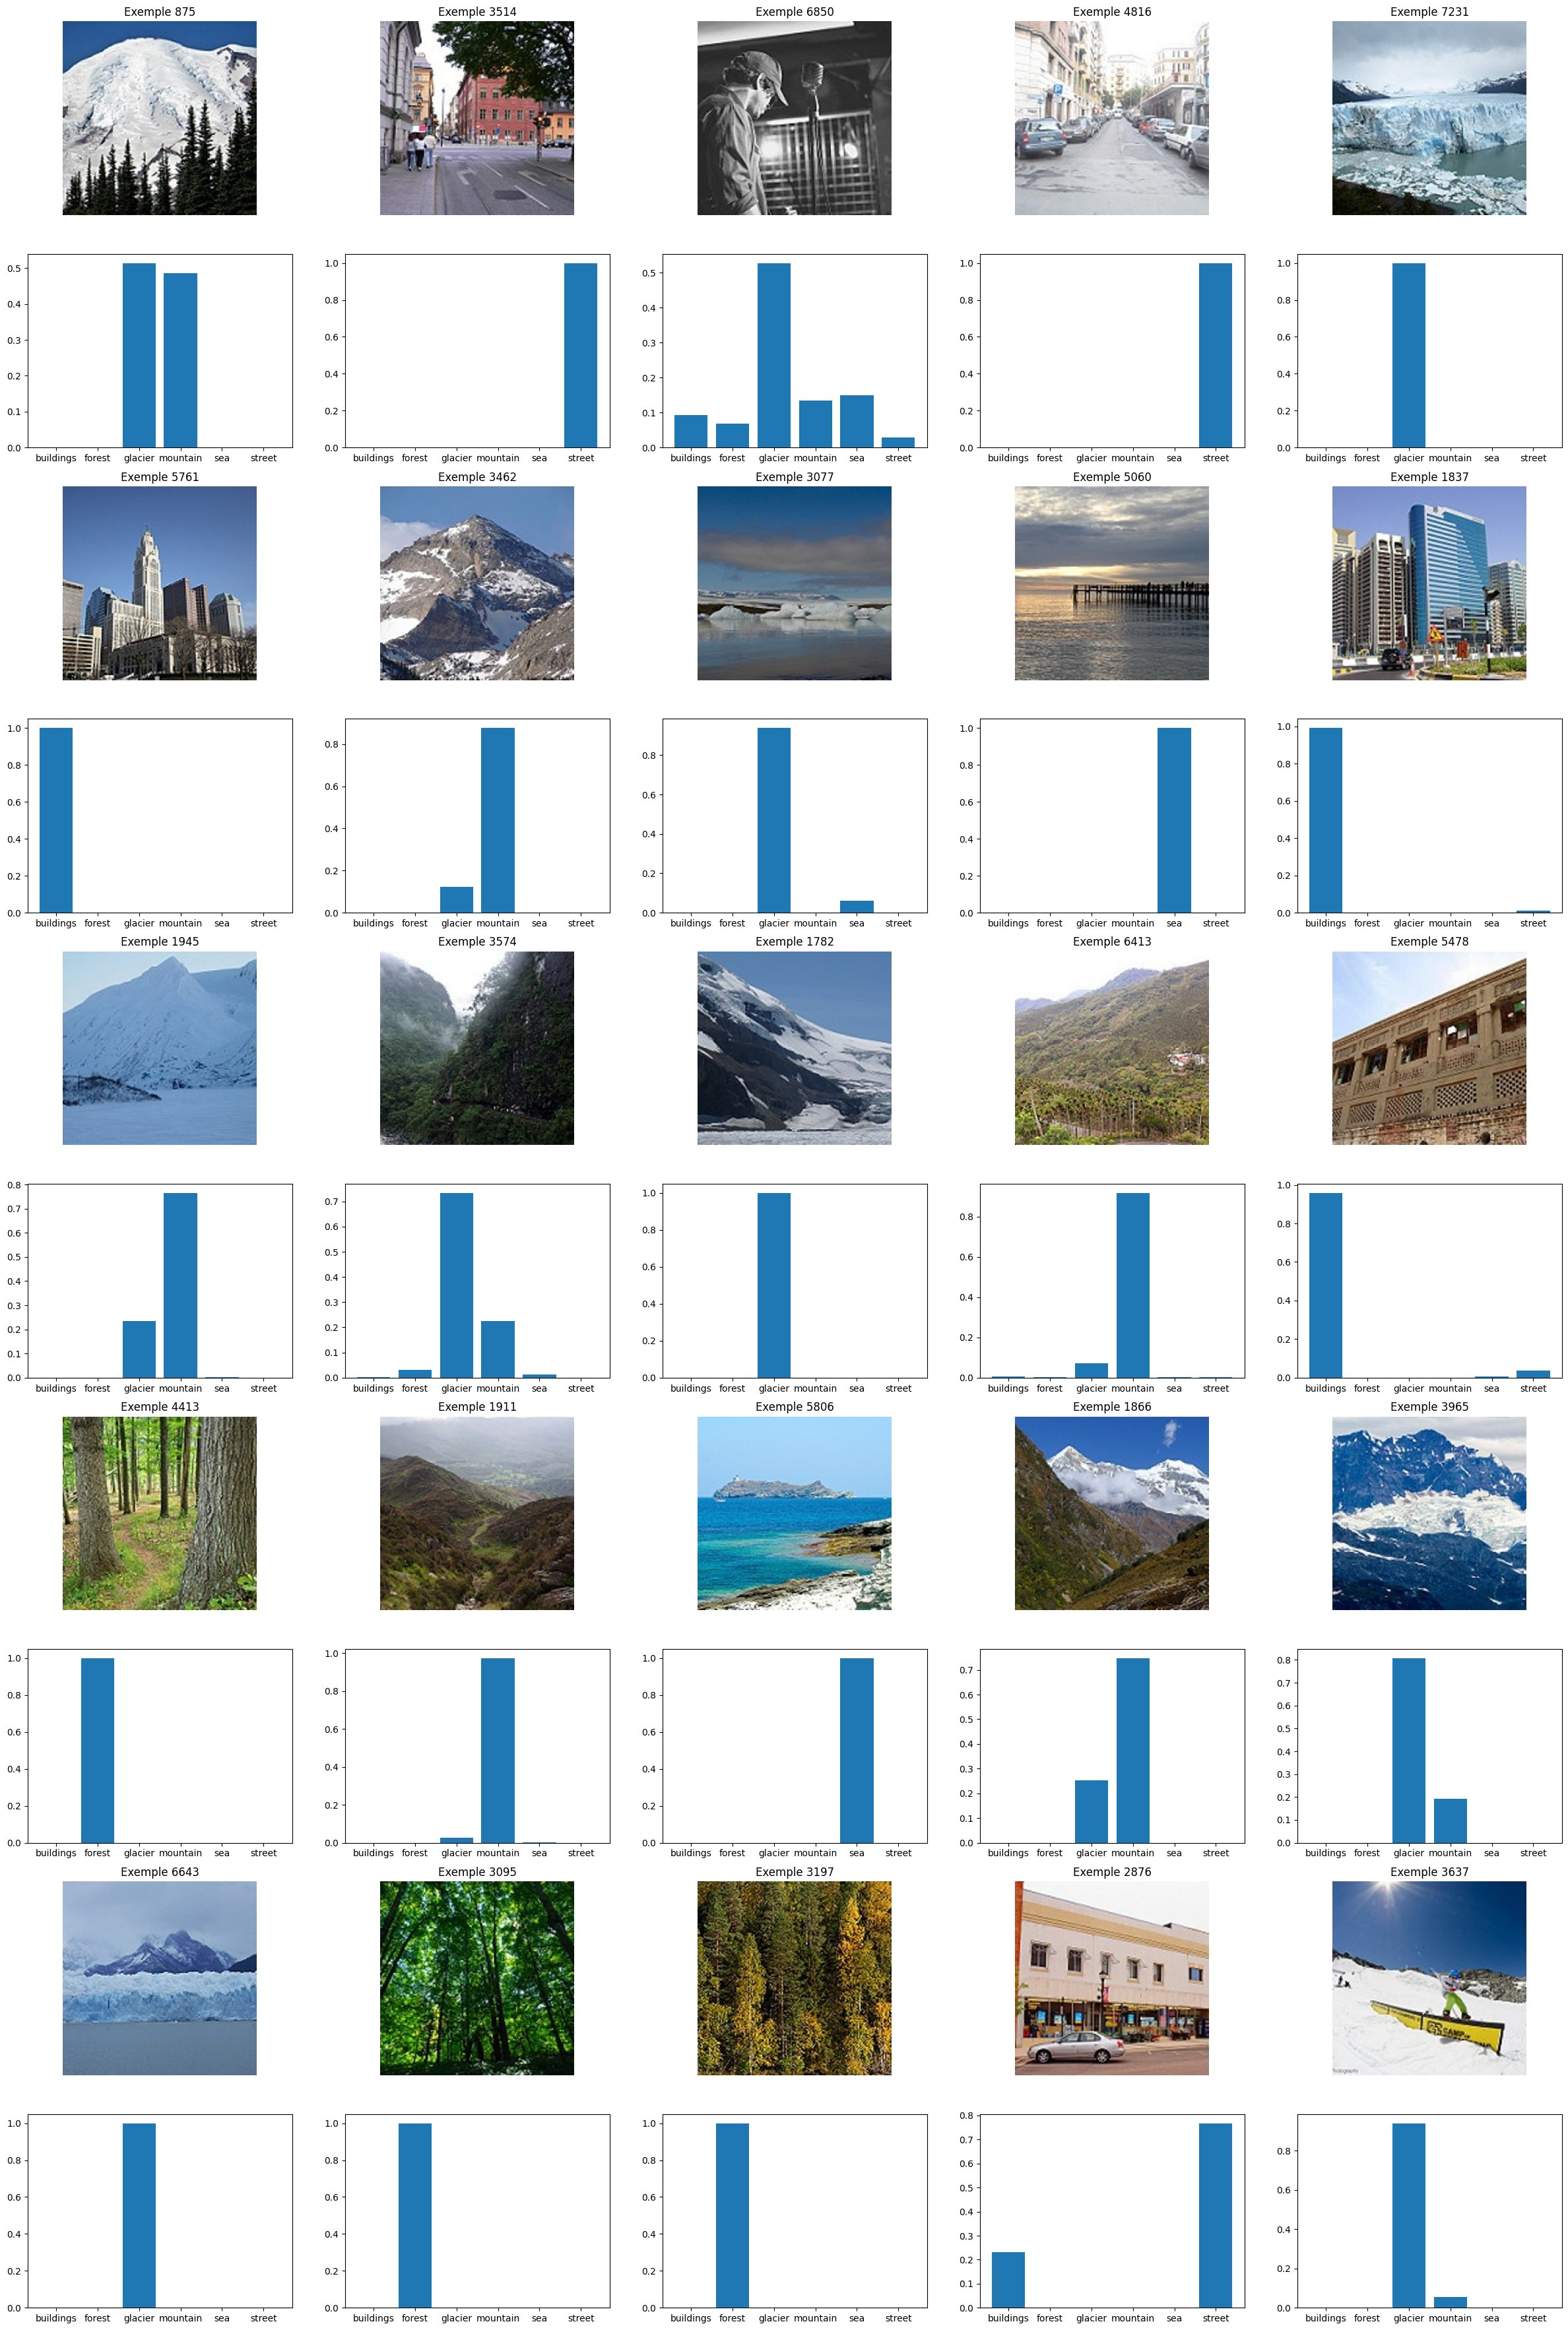

In [32]:
# Création de la grille de sous-plots. On donne l'argument figsize pour agrandir
# la taille de la figure qui est petite par défaut
_, ax = plt.subplots(10, 5, figsize=(30, 45))

# On choisit 25 indices au hasard, sans replacement (on ne veut pas afficher la
# même image deux fois)
random_indexes = numpy.random.choice(pred_images.shape[0],
                                     size=(5, 5),
                                     replace=False)

for i in range(5):
  for j in range(5):
    img_index = random_indexes[i, j]
    # Récupération de l'image et prédiction de sa classe
    image = pred_images[img_index]
    probabilities = transferred_transformer.predict(image[None, ...])[0]
    predicted_class = label_names[numpy.argmax(probabilities)]

    # Affichage avec matplotlib et sa fonction imshow, très pratique en vision
    # par ordinateur
    ax[i * 2, j].imshow(tf.transpose(image, perm=(1, 2, 0)))
    ax[i * 2, j].set_title(f"Exemple {img_index}")
    ax[i * 2, j].axis('off')

    # Affichage de la distribution de prédiction sur la ligne d'en dessous
    ax[i * 2 + 1, j].bar(label_names, probabilities)

## Analyse par occlusion

In [33]:
images, labels = get_images(pathlib.Path("landscape") / "seg_train")

Traitement des dossiers:   0%|          | 0/6 [00:00<?, ?it/s]

Dossier buildings:   0%|          | 0/2191 [00:00<?, ?it/s]

Dossier forest:   0%|          | 0/2271 [00:00<?, ?it/s]

Dossier glacier:   0%|          | 0/2404 [00:00<?, ?it/s]

Dossier mountain:   0%|          | 0/2512 [00:00<?, ?it/s]

Dossier sea:   0%|          | 0/2274 [00:00<?, ?it/s]

Dossier street:   0%|          | 0/2382 [00:00<?, ?it/s]

Classe réelle : forest
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Proba de la bonne classe avec l'image complète : 0.9999782


  0%|          | 0/169 [00:00<?, ?it/s]

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 518ms/step


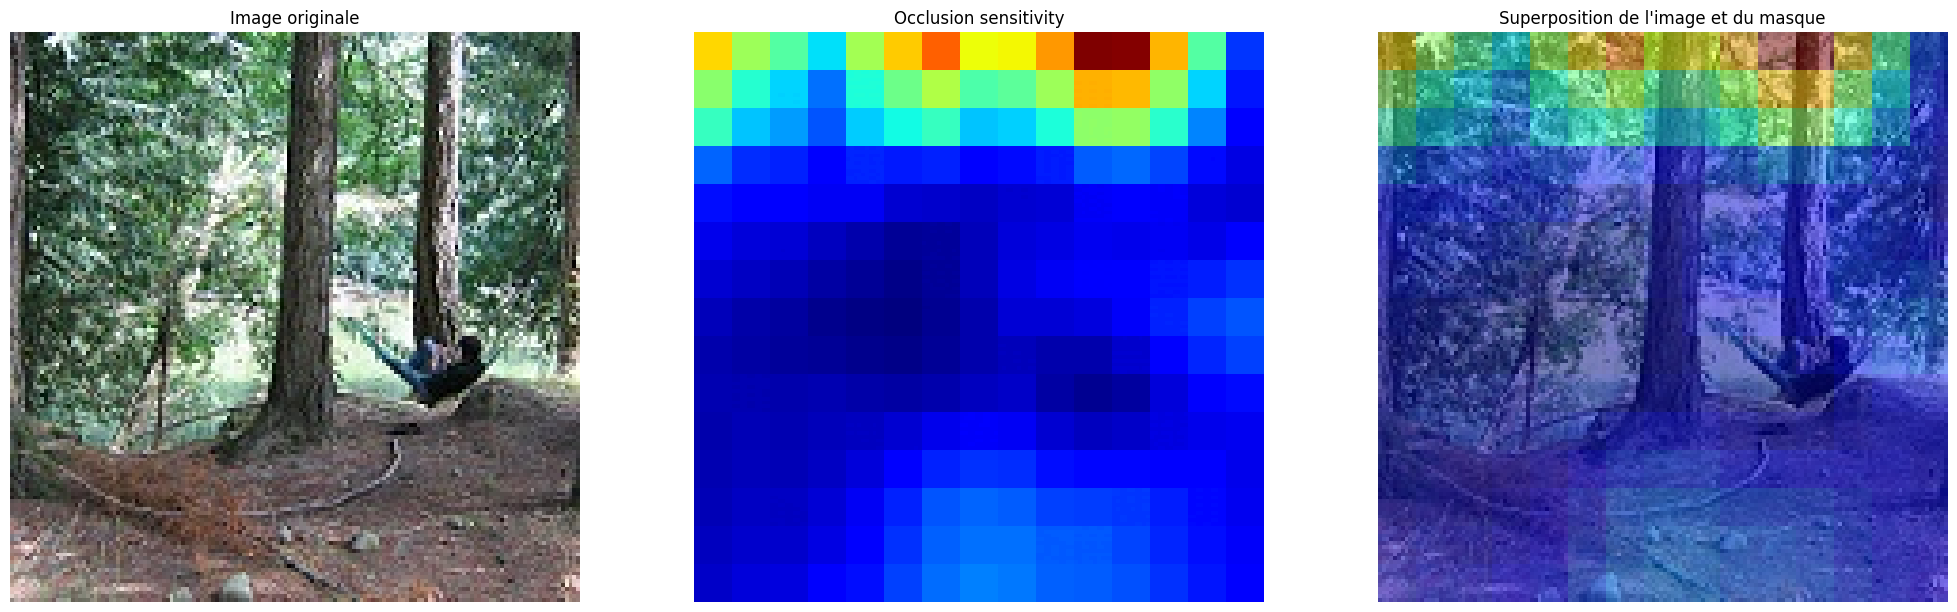

In [34]:
def occlusion_analysis(image: tf.Tensor,
                       label: int,
                       size: int = 30,
                       step: int = 10
                       ) -> None:
  print("Classe réelle :", label_names[label])
  label_prob_full = deep_cnn.predict(image[None, ...])[0, label]
  print("Proba de la bonne classe avec l'image complète :",
        label_prob_full)
  height, width = image.shape[:2]
  n_height = image.shape[0] - size + 1
  n_width = image.shape[1] - size + 1
  occluded_images = []
  mask = tf.cast(tf.fill(image.shape, 127), tf.uint8)
  ones = tf.ones(size, dtype="uint8")
  ii = list(range(0, n_height, step))
  jj = list(range(0, n_width, step))
  for i, j in tqdm.notebook.tqdm(list(itertools.product(ii, jj)), leave=False):
    indices_height = tf.pad(ones, [[i, height - size - i]])
    indices_width = tf.pad(ones, [[j, width - size - j]])
    indices = (indices_height[:, None] * indices_width[None, :])[..., None]
    occluded_images.append(tf.where(tf.cast(indices, tf.bool), mask, image))
  weights = tf.nn.conv2d_transpose(tf.ones((1, len(ii), len(jj), 1)),
                                   tf.ones((size, size, 1, 1)),
                                   (1, *image.shape[:2], 1),
                                   step,
                                   padding="VALID")
  occluded_images_tensor = tf.stack(occluded_images)
  preds = deep_cnn.predict(occluded_images_tensor).reshape(len(ii), len(jj), -1)
  label_preds = preds[None, ..., label, None]
  heatmap = tf.nn.conv2d_transpose(label_preds,
                                   tf.ones((size, size, 1, 1)),
                                   (1, *image.shape[:2], 1),
                                   step,
                                   padding="VALID")
  heatmap /= weights
  heatmap *= -1
  heatmap -= numpy.min(heatmap)
  heatmap /= numpy.max(heatmap)
  heatmap *= 255

  heatmap = numpy.array(heatmap).astype(numpy.uint8)[0,:,:,:]
  # Use jet colormap to colorize heatmap
  jet = matplotlib.colormaps["jet"]

  # Use RGB values of the colormap
  jet_colors = jet(numpy.arange(256))[:, :3]
  jet_heatmap = jet_colors[heatmap][:,:,0,:]
  # Create an image with RGB colorized heatmap
  jet_heatmap = skimage.transform.resize(jet_heatmap, (image.shape[0], image.shape[1]))


  fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(25, 8))
  ax1.imshow(image)
  ax1.axis("off")
  ax1.set_title("Image originale")
  ax2.imshow(jet_heatmap)
  ax2.axis("off")
  ax2.set_title("Occlusion sensitivity")
  #ax3.imshow(superimposed_img)
  ax3.imshow(image)
  ax3.imshow(jet_heatmap, alpha = 0.5)
  ax3.axis("off")
  ax3.set_title("Superposition de l'image et du masque")
  plt.show()


i = 600
occlusion_analysis(images[i], labels[i])

## À retenir

Accuracy sur l'ensemble de validation lors d'une exécution complète (`SHORT_RUN = False`) sur un T4. La version courte donne des scores plus bas.

| Modèle | Entraînement | Accuracy (validation) |
| --- | --- | --- |
| CNN minimaliste (1 convolution) | de zéro, 1 epoch | 22 à 26 % |
| CNN profond (6 convolutions) | de zéro, 15 epochs | 84 % |
| EfficientNetV2B0 pré-entraîné sur ImageNet | transfert, 5 epochs | 90 % |
| ViT pré-entraîné sur ImageNet-21k | transfert, 3 epochs | 94 % |

- Le hasard donnerait environ 17 % (6 classes) : le CNN minimaliste apprend à peine. La profondeur du réseau compte.
- Entraîner un réseau profond de zéro coûte cher : c'est l'étape la plus longue de ce notebook, et elle a besoin de beaucoup d'images.
- Le transfert d'apprentissage réutilise un modèle déjà entraîné sur des millions d'images et n'entraîne que les couches ajoutées : en quelques epochs, il fait mieux. C'est le point de départ par défaut d'un projet de vision par ordinateur.
- Les erreurs restantes portent souvent sur des classes proches, comme glacier et montagne : la matrice de confusion et les images mal classées le montrent, et certaines de ces images sont ambiguës même pour un humain.
- L'analyse par occlusion montre quelles zones de l'image comptent pour la prédiction : un moyen simple de vérifier que le modèle regarde au bon endroit.